# Libraries 

In [49]:
import os
import pandas as pd
import numpy as np
from skimage.io import imread, imsave
import matplotlib.pyplot as plt
import cv2
import zipfile
import shutil
import math
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)

# Useful functions 

In [2]:
def resize_image(img, scale_percent):
    """
    Resizes an image to a given percentage of the original.

    Parameters
    ----------
    img : numpy darray
        Image to resize
    scale_percent : float
        Scaling percent for resizing

    Returns
    -------
    resized : numpy darray
        The resized image

    """

    width = int(img.shape[1] * scale_percent / 100)
    height = int(img.shape[0] * scale_percent / 100)

    if scale_percent <= 100:
        resized = cv2.resize(img, (width, height),
                             interpolation=cv2.INTER_AREA)
    else:
        resized = cv2.resize(img, (width, height),
                             interpolation=cv2.INTER_LINEAR)

    return(resized)


def invert_grayscale(img):
    """ Inverts the grayscale of an image. """

    inverted_img = 255 - img

    return(inverted_img)

In [45]:
def plot_track_and_vignettes_VLFR(df_particles, disp_step, save_path=None):
    """
    Plots the track of particles and side-by-side vignettes of each particle.

    Parameters
    ----------
    df_particles : pandas.DataFrame
        DataFrame containing particle data. Each row corresponds to a particle with 
        columns for the x and y coordinates, track_id, and the particle orientation.
    disp_step : int
        Step for displaying every nth particle.
    save_path : str, optional
        Path to save the figure.
    """
    try:

        # --- Figure and gridspec ---
        ncols = 4 + math.ceil((len(df_particles)/3) / 4)
        nrows = 4

        fig_width = max(14, ncols * 2)  # total figure width can scale for vignettes
        fig_height = 6                  # fixed figure height

        fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)
        gs = fig.add_gridspec(nrows, ncols)

        # --- Main track subplot with fixed size ---
        ax1 = fig.add_subplot(gs[0:5, :3])
        ax1.set_box_aspect(1)  # keeps ax1 square, independent of ncols

        # Extract coordinates
        x = df_particles['coord_x']
        y = df_particles['coord_y']

        # Indices for displayed points
        idx_black = np.arange(0, len(df_particles), disp_step)
        idx_white = np.array([i for i in range(len(df_particles)) if i not in idx_black])

        # Plot points
        ax1.scatter(x.iloc[idx_white], y.iloc[idx_white],
                    marker='o', facecolors='white', edgecolors='black', s=25, linewidths=1)
        ax1.scatter(x.iloc[idx_black], y.iloc[idx_black],
                    marker='o', color='black', s=40)

        # Highlight first and last points
        ax1.plot(x.iloc[0], y.iloc[0], marker='o', color='green', markersize=7, linestyle='None', label=r'$t_0$')
        ax1.plot(x.iloc[-1], y.iloc[-1], marker='o', color='red', markersize=7, linestyle='None', label=r'$t_f$')

        # Speeds and orientation
        raw_speed = df_particles['vertical_speed'].iloc[0]
        corrected_speed = df_particles['corrected_by_poly'].iloc[0]
        orientation_corrected = df_particles['orientation_corrected'].iloc[0]

        # Mean ESD
        mean_esd = df_particles['esd_um'].mean()

        # Axes limits
        ax1.set_xlim(0, 2464)
        ax1.set_ylim(0, 2056)
        ax1.invert_yaxis()

        # Suptitle with mean ESD
        fig.suptitle(
            r"$\bf{ID:}$ " + f"{df_particles['track_id'].iloc[0]}, "
            r"$\bf{ESD:}$ " + f"{round(mean_esd)} µm, "
            r"$\bf{Raw\ VS:}$ " + f"{round(raw_speed)} m·d$^{{-1}}$, "
            r"$\bf{Corrected\ VS:}$ " + f"{round(corrected_speed)} m·d$^{{-1}}$, "
            r"$\bf{Orientation:}$ " + f"{orientation_corrected}",
            fontsize=12, color='black', x=0.01, ha='left'
        )
        # Scale bar
        bar_length = 137  # in image pixel units (= 1 cm)
        bar_y = 2000
        bar_x = 75  
    
        ax1.plot([bar_x, bar_x + bar_length], [bar_y, bar_y], color='grey', linewidth=2, solid_capstyle='butt')
        ax1.plot([bar_x, bar_x], [bar_y, bar_y - bar_length], color='grey', linewidth=2, solid_capstyle='butt')
        # Axes labels
        size = 12
        ax1.set_xlabel('Horizontal axis (pixels)', size=size)
        ax1.set_ylabel('Vertical axis (pixels)', size=size)
        for spine in ax1.spines.values():
            spine.set_linewidth(2)

        # Legend fixed to top-left of ax1
        legend1 = ax1.legend(loc='upper left', bbox_to_anchor=(0, 1),
                             labelspacing=0.5, fontsize=size, markerscale=1,
                             handletextpad=0.5, borderpad=1,
                             edgecolor='black', frameon=True, framealpha=1,
                             fancybox=True, shadow=True, ncol=1)
        legend1.get_frame().set_linewidth(1.5)

        # --- Vignettes ---
        ct_col, ct_row = 3, 4
        vignette_axes = []
        indices = [0] + list(range(disp_step, len(df_particles) - 1, disp_step)) + [len(df_particles) - 1]
        for i, row in df_particles.iloc[indices].iterrows():
            ncol = math.trunc(ct_col)
            ct_col += 0.25
            nrow = ct_row % 4
            ct_row += 1

            img = imread(row['filename'])

            # Crop window
            esd_px = row['esd_px']
            window = esd_px + 4
            right = min(int(row['coord_x'] + window), 2464)
            left = max(0, int(row['coord_x'] - window))
            top = max(0, int(row['coord_y'] - window))
            bott = min(int(row['coord_y'] + window), 2056)
            crop = img[top:bott, left:right]

            width, height = crop.shape[1] * 73 / 1000, crop.shape[0] * 73 / 1000
            crop = invert_grayscale(resize_image(crop, 750))

            ax = fig.add_subplot(gs[nrow, ncol])
            vignette_axes.append(ax)
            ax.imshow(crop, cmap='gray', extent=[0, width, height, 0], vmin=0, vmax=255)

            step_num = row['step_num']
            ax.set_title(f"{step_num} | (mm)", fontsize=8)
            l, w, pad = 4, 1.5, 4
            ax.tick_params(axis="x", labelsize=8, pad=pad, length=l, width=w)
            ax.tick_params(axis="y", labelsize=8, pad=pad, length=l, width=w)
            for spine in ax.spines.values():
                spine.set_linewidth(1.5)

        # Highlight first and last vignettes
        for spine in vignette_axes[0].spines.values():
            spine.set_linewidth(2)
            spine.set_edgecolor('green')
        for spine in vignette_axes[-1].spines.values():
            spine.set_linewidth(2)
            spine.set_edgecolor('red')

        plt.tight_layout(h_pad=0.2)

        if save_path:
            try:
                filename = f"{save_path}/{df_particles['track_id'].iloc[0]}_{orientation_corrected}.png"
                plt.savefig(filename, dpi=300)
                plt.show()
                plt.close()
            except Exception as e:
                print(f"Could not save figure: {e}")

        plt.show()

    except Exception as e:
        print(f"Could not create the figure: {e}")

# Import selected tracks from VLFR cruise

In [18]:
VLFR_tracks = pd.read_csv('/home/aaccardo/these_alex/Analysis/APERO/TZEX/vlfr_test/Data/sinking_speeds/correction_selection_poly/selected_tracks_by_interquartile_vlfr_poly_no_living.csv')


VLFR_tracks['orientation_raw'] = np.where(VLFR_tracks['vertical_speed'] < 0, 'asc', 'desc')
VLFR_tracks['orientation_corrected'] = np.where(VLFR_tracks['corrected_by_poly'] < 0, 'asc', 'desc')
VLFR_tracks = VLFR_tracks[['track_id', 'orientation_corrected', 'orientation_raw', 'vertical_speed', 'corrected_by_poly', 'esd_um']]
VLFR_tracks

,track_id,orientation_corrected,orientation_raw,vertical_speed,corrected_by_poly,esd_um
0,vlfr_20230418-142403-1-418,asc,desc,94.296297,-73.375225,114.971982
1,vlfr_20230418-142413-1-608,desc,desc,258.038728,91.721063,455.286457
2,vlfr_20230418-142426-1-958,desc,desc,228.438677,63.854057,304.382251
3,vlfr_20230418-142511-1-2256,desc,desc,236.135415,77.394113,363.951173
4,vlfr_20230418-142605-1-3707,desc,desc,215.745130,68.070449,496.847746
...,...,...,...,...,...,...
461,vlfr_20230501-231957-1-10371,asc,asc,-140.192296,-56.134440,195.102155
462,vlfr_20230501-232003-1-10572,asc,asc,-154.435880,-69.149905,205.712784
463,vlfr_20230501-232004-1-10588,asc,asc,-141.559343,-56.078112,191.745555
464,vlfr_20230501-232007-1-10668,desc,asc,-48.941032,36.758480,124.717871


# Import the dataframe with informations on particle at each step of each track

In [19]:
all_df = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/MBARI_tracks_all.tsv', delimiter = '\t')
all_df['datetime'] = all_df['datetime'].str.replace('.000', '') # remove the .000 part from the datetime value
all_df['datetime'] = all_df['datetime'].str.replace('.500', '') # same for the .500
all_df['datetime'] = pd.to_datetime(all_df['datetime']) # convert to datetime
VLFR_all_df = all_df.drop(['vertical_speed', 'orientation'], axis=1) # drop vertical_speed and orientation columns because they are already in the summary dataframe
VLFR_all_df = VLFR_all_df[['track_id', 'sequence', 'coord_x', 'coord_y', 'esd_px', 'filename']]
VLFR_all_df

,track_id,sequence,coord_x,coord_y,esd_px,filename
0,vlfr_20230418-062656-1-5327,20230418-062321,80.545455,47.545455,3.742410,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
1,vlfr_20230418-062656-1-5327,20230418-062321,95.333333,60.222222,3.385138,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
2,vlfr_20230418-062656-1-5327,20230418-062321,106.000000,68.000000,2.256758,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
3,vlfr_20230418-062656-1-5327,20230418-062321,111.333333,71.500000,2.763953,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
4,vlfr_20230418-062656-1-5327,20230418-062321,112.200000,73.400000,2.523133,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
...,...,...,...,...,...,...
714297,vlfr_20230503-013544-1-678,20230503-013458,280.666667,1253.333333,1.954410,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
714298,vlfr_20230503-013544-1-678,20230503-013458,274.666667,1245.666667,1.954410,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
714299,vlfr_20230503-013544-1-678,20230503-013458,268.500000,1237.500000,2.256758,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
714300,vlfr_20230503-013544-1-678,20230503-013458,262.000000,1228.250000,2.256758,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...


# Merge both dataframe 

In [20]:
VLFR_tracks = pd.merge(VLFR_tracks, VLFR_all_df, on = 'track_id')
VLFR_tracks

,track_id,orientation_corrected,orientation_raw,vertical_speed,corrected_by_poly,esd_um,sequence,coord_x,coord_y,esd_px,filename
0,vlfr_20230418-142403-1-418,asc,desc,94.296297,-73.375225,114.971982,20230418-142321,54.600000,293.200000,2.523133,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
1,vlfr_20230418-142403-1-418,asc,desc,94.296297,-73.375225,114.971982,20230418-142321,59.333333,308.333333,1.954410,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
2,vlfr_20230418-142403-1-418,asc,desc,94.296297,-73.375225,114.971982,20230418-142321,63.333333,323.333333,1.954410,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
3,vlfr_20230418-142403-1-418,asc,desc,94.296297,-73.375225,114.971982,20230418-142321,67.500000,338.000000,2.256758,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
4,vlfr_20230418-142403-1-418,asc,desc,94.296297,-73.375225,114.971982,20230418-142321,71.750000,353.000000,2.256758,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
...,...,...,...,...,...,...,...,...,...,...,...
6690,vlfr_20230501-232018-1-10906,desc,asc,-45.612549,42.969573,126.903307,20230501-231319,152.250000,1400.000000,2.256758,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
6691,vlfr_20230501-232018-1-10906,desc,asc,-45.612549,42.969573,126.903307,20230501-231319,154.400000,1391.800000,2.523133,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
6692,vlfr_20230501-232018-1-10906,desc,asc,-45.612549,42.969573,126.903307,20230501-231319,156.750000,1384.000000,2.256758,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...
6693,vlfr_20230501-232018-1-10906,desc,asc,-45.612549,42.969573,126.903307,20230501-231319,158.600000,1375.800000,2.523133,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...


In [21]:
VLFR_tracks['filename'].iloc[0]

'/home/aaccardo/these_alex/Analysis/APERO/TZEX/vlfr_test/raw/20230418-142321/1/20230418-142403-1.png'

# Modify the path in filename column to fit with the folder where the images will be pasted

In [22]:
VLFR_tracks['filename'] = VLFR_tracks['filename'].str.replace('/these_alex/Analysis/APERO/TZEX/vlfr_test/raw/', '/these_alex/Papers/Rising_stars/Track_plots/copy_raw/')
VLFR_tracks['filename'].iloc[0]

'/home/aaccardo/these_alex/Papers/Rising_stars/Track_plots/copy_raw/20230418-142321/1/20230418-142403-1.png'

# Select only particles with esd > 600 µm

In [23]:
VLFR_tracks = VLFR_tracks[VLFR_tracks['esd_um'] >= 300]
VLFR_tracks

,track_id,orientation_corrected,orientation_raw,vertical_speed,corrected_by_poly,esd_um,sequence,coord_x,coord_y,esd_px,filename
5,vlfr_20230418-142413-1-608,desc,desc,258.038728,91.721063,455.286457,20230418-142321,1895.192308,1275.115385,5.753627,/home/aaccardo/these_alex/Papers/Rising_stars/...
6,vlfr_20230418-142413-1-608,desc,desc,258.038728,91.721063,455.286457,20230418-142321,1908.424242,1315.030303,6.482045,/home/aaccardo/these_alex/Papers/Rising_stars/...
7,vlfr_20230418-142413-1-608,desc,desc,258.038728,91.721063,455.286457,20230418-142321,1921.230769,1354.461538,5.753627,/home/aaccardo/these_alex/Papers/Rising_stars/...
8,vlfr_20230418-142413-1-608,desc,desc,258.038728,91.721063,455.286457,20230418-142321,1934.458333,1394.000000,5.527906,/home/aaccardo/these_alex/Papers/Rising_stars/...
9,vlfr_20230418-142413-1-608,desc,desc,258.038728,91.721063,455.286457,20230418-142321,1947.314286,1432.857143,6.675581,/home/aaccardo/these_alex/Papers/Rising_stars/...
...,...,...,...,...,...,...,...,...,...,...,...
5980,vlfr_20230501-063436-1-1392,desc,asc,-9.710262,70.628058,471.346139,20230501-063321,1170.895833,586.770833,7.817640,/home/aaccardo/these_alex/Papers/Rising_stars/...
5981,vlfr_20230501-063436-1-1392,desc,asc,-9.710262,70.628058,471.346139,20230501-063321,1184.000000,584.400000,7.978846,/home/aaccardo/these_alex/Papers/Rising_stars/...
5982,vlfr_20230501-063436-1-1392,desc,asc,-9.710262,70.628058,471.346139,20230501-063321,1196.916667,582.520833,7.817640,/home/aaccardo/these_alex/Papers/Rising_stars/...
5983,vlfr_20230501-063436-1-1392,desc,asc,-9.710262,70.628058,471.346139,20230501-063321,1210.490909,580.036364,8.368284,/home/aaccardo/these_alex/Papers/Rising_stars/...


In [24]:
VLFR_tracks['step_num'] = VLFR_tracks.groupby('track_id').cumcount()
VLFR_tracks

,track_id,orientation_corrected,orientation_raw,vertical_speed,corrected_by_poly,esd_um,sequence,coord_x,coord_y,esd_px,filename,step_num
5,vlfr_20230418-142413-1-608,desc,desc,258.038728,91.721063,455.286457,20230418-142321,1895.192308,1275.115385,5.753627,/home/aaccardo/these_alex/Papers/Rising_stars/...,0
6,vlfr_20230418-142413-1-608,desc,desc,258.038728,91.721063,455.286457,20230418-142321,1908.424242,1315.030303,6.482045,/home/aaccardo/these_alex/Papers/Rising_stars/...,1
7,vlfr_20230418-142413-1-608,desc,desc,258.038728,91.721063,455.286457,20230418-142321,1921.230769,1354.461538,5.753627,/home/aaccardo/these_alex/Papers/Rising_stars/...,2
8,vlfr_20230418-142413-1-608,desc,desc,258.038728,91.721063,455.286457,20230418-142321,1934.458333,1394.000000,5.527906,/home/aaccardo/these_alex/Papers/Rising_stars/...,3
9,vlfr_20230418-142413-1-608,desc,desc,258.038728,91.721063,455.286457,20230418-142321,1947.314286,1432.857143,6.675581,/home/aaccardo/these_alex/Papers/Rising_stars/...,4
...,...,...,...,...,...,...,...,...,...,...,...,...
5980,vlfr_20230501-063436-1-1392,desc,asc,-9.710262,70.628058,471.346139,20230501-063321,1170.895833,586.770833,7.817640,/home/aaccardo/these_alex/Papers/Rising_stars/...,16
5981,vlfr_20230501-063436-1-1392,desc,asc,-9.710262,70.628058,471.346139,20230501-063321,1184.000000,584.400000,7.978846,/home/aaccardo/these_alex/Papers/Rising_stars/...,17
5982,vlfr_20230501-063436-1-1392,desc,asc,-9.710262,70.628058,471.346139,20230501-063321,1196.916667,582.520833,7.817640,/home/aaccardo/these_alex/Papers/Rising_stars/...,18
5983,vlfr_20230501-063436-1-1392,desc,asc,-9.710262,70.628058,471.346139,20230501-063321,1210.490909,580.036364,8.368284,/home/aaccardo/these_alex/Papers/Rising_stars/...,19


In [25]:
sequences = VLFR_tracks['sequence'].unique().tolist()
total_sequences = len(sequences)
count_seq = 0 

In [26]:
track_id = VLFR_tracks['track_id'].unique().tolist()
len(track_id)

47

In [27]:
total_tracks = len(track_id)
count = 0 

Processing sequence 5/19: 20230418-142321
extract images from server to local
Processing track 0/5: vlfr_20230418-142413-1-608


/tmp/ipykernel_929291/3024365693.py:208: UserWarning: The figure layout has changed to tight
  plt.tight_layout(h_pad=0.2)


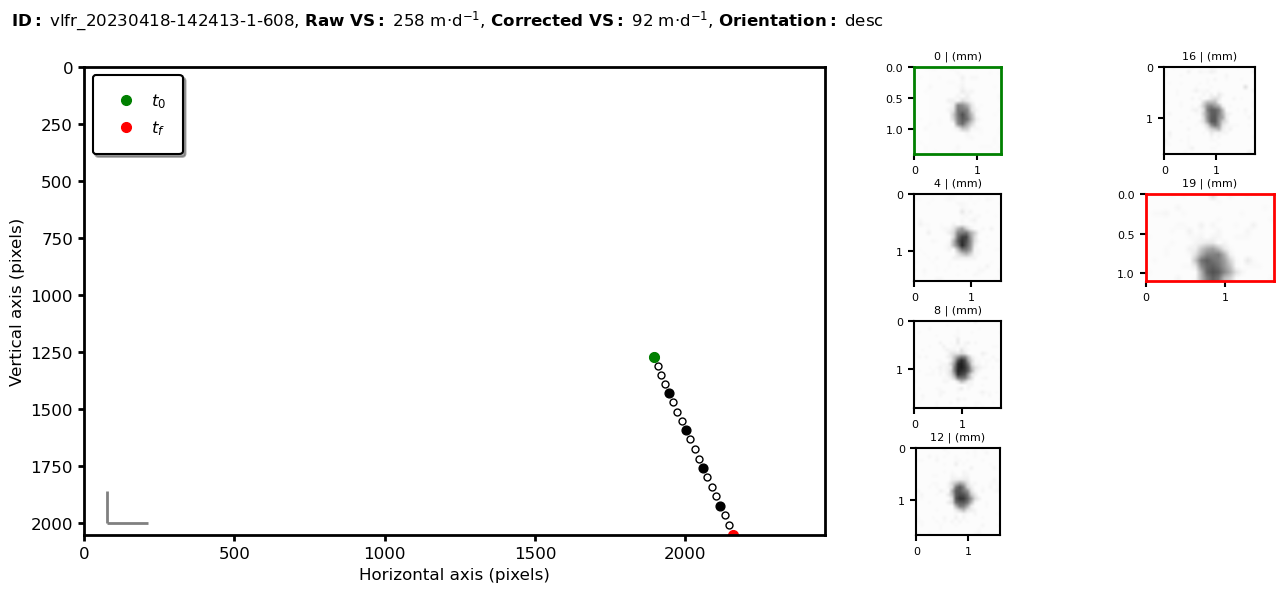

Processing track 0/5: vlfr_20230418-142426-1-958


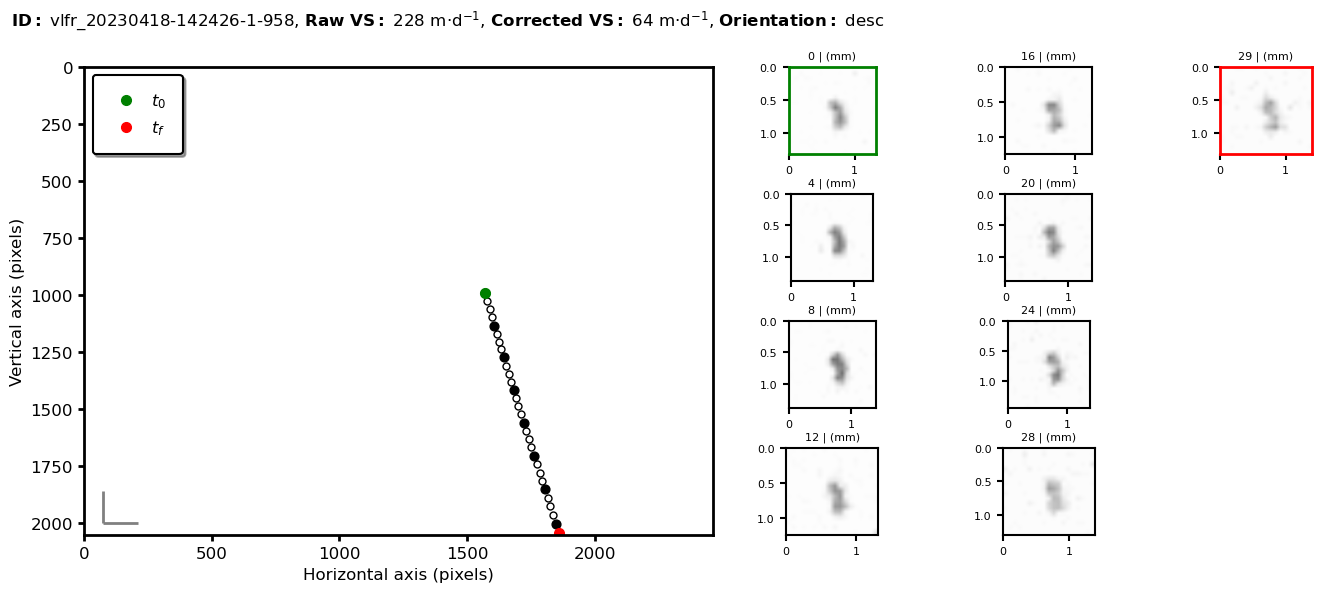

Processing track 0/5: vlfr_20230418-142511-1-2256


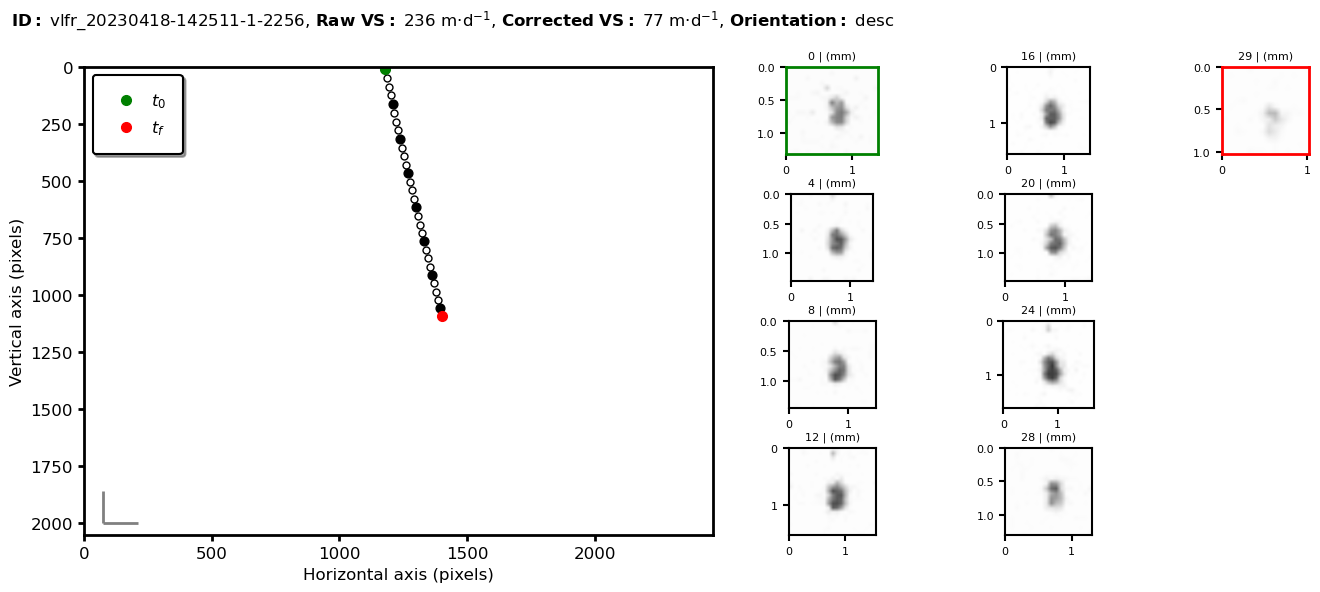

Processing track 0/5: vlfr_20230418-142605-1-3707


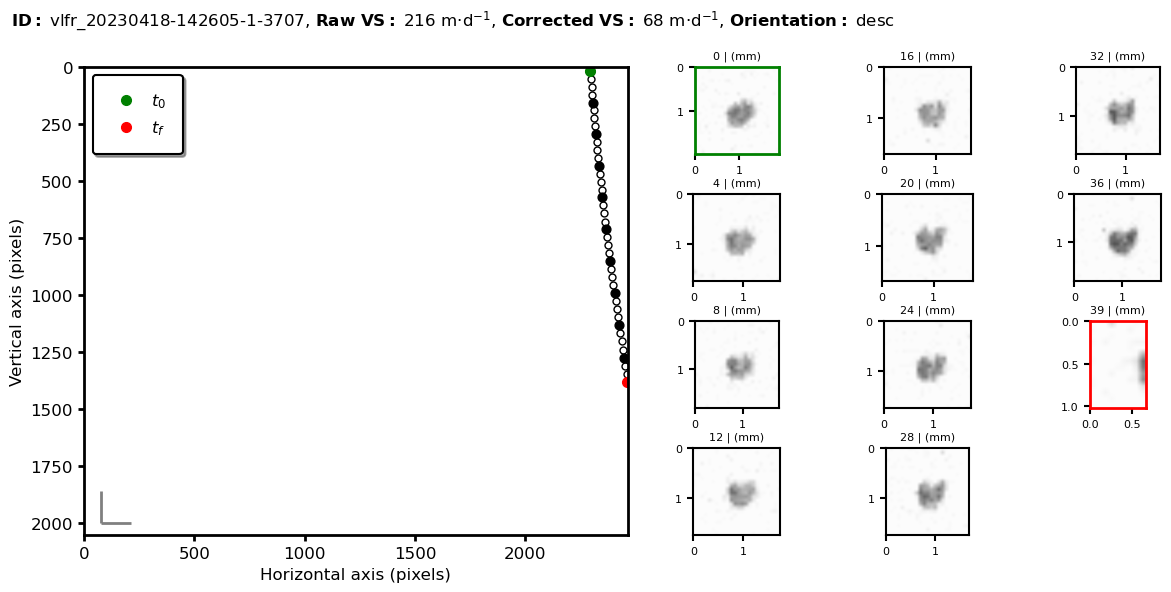

Processing track 0/5: vlfr_20230418-142625-1-4135


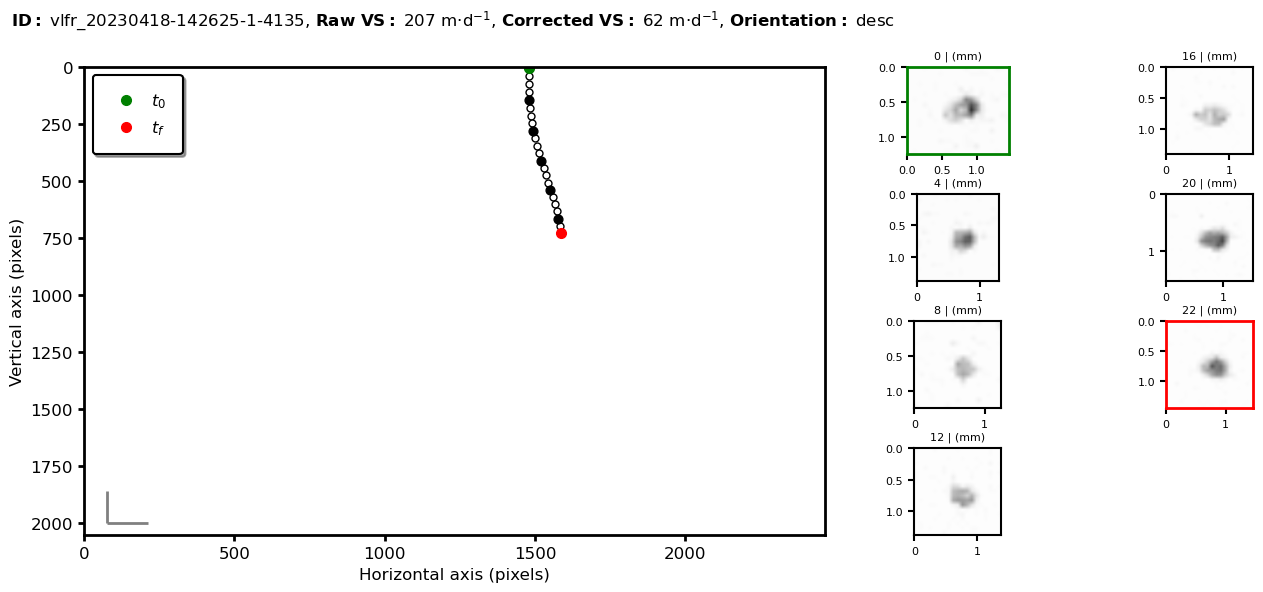

Process done for this sequence.
Delete images from local
Processing sequence 6/19: 20230419-213817
extract images from server to local
Processing track 0/1: vlfr_20230419-214418-1-10807


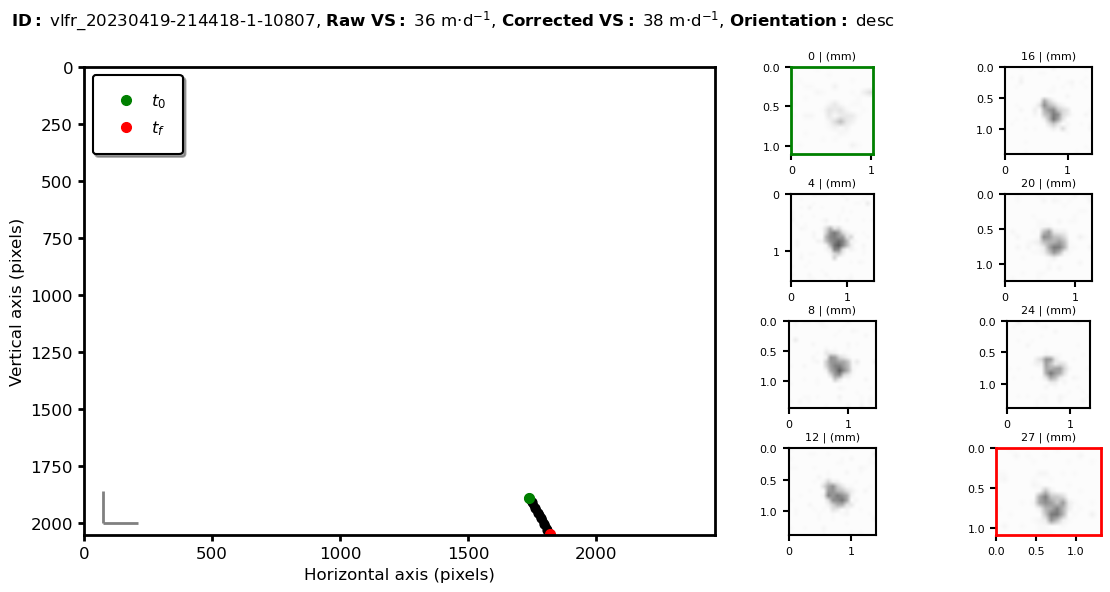

Process done for this sequence.
Delete images from local
Processing sequence 7/19: 20230421-065822
extract images from server to local
Processing track 0/2: vlfr_20230421-070235-1-5070


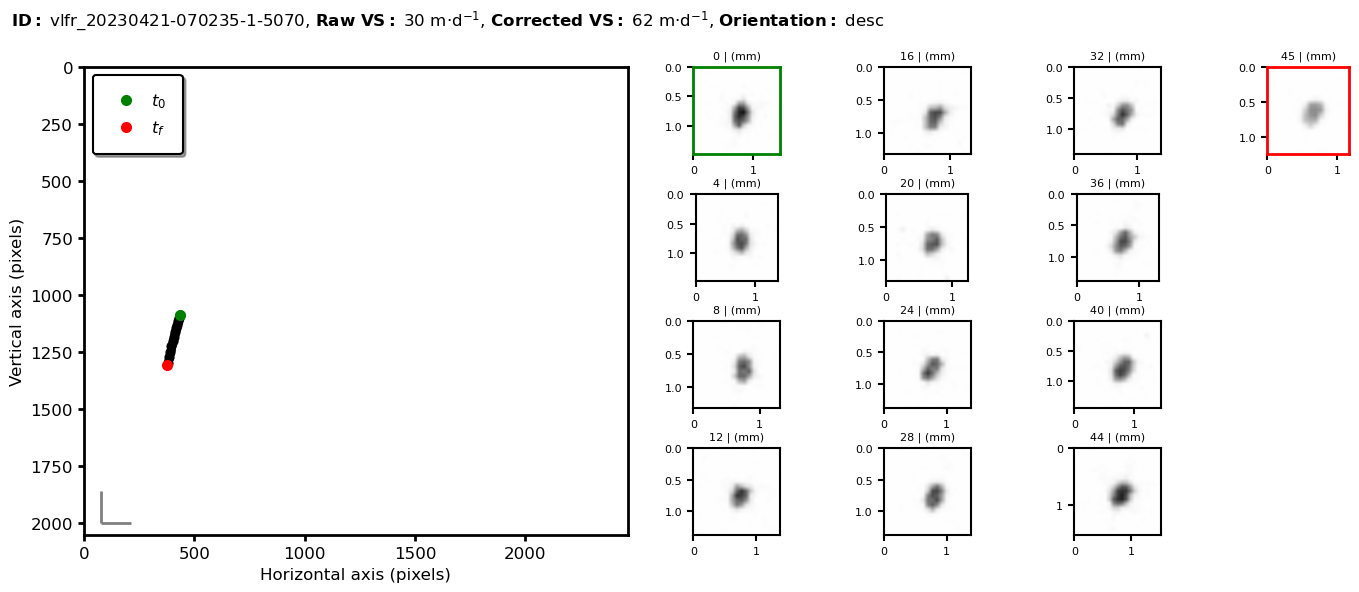

Processing track 0/2: vlfr_20230421-070348-1-6689


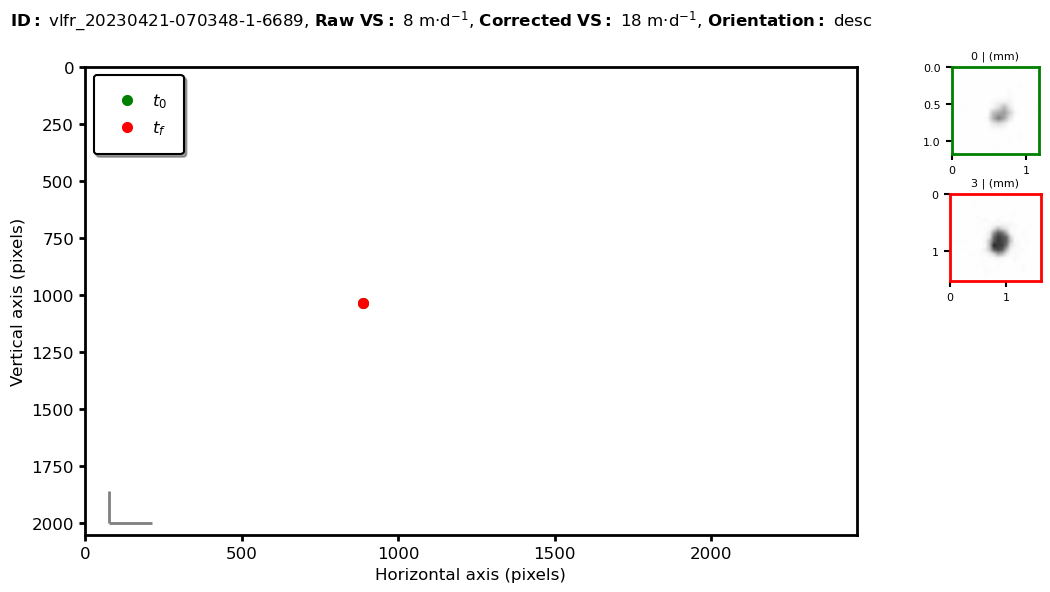

Process done for this sequence.
Delete images from local
Processing sequence 8/19: 20230421-073822
extract images from server to local
Processing track 0/1: vlfr_20230421-074420-1-7411


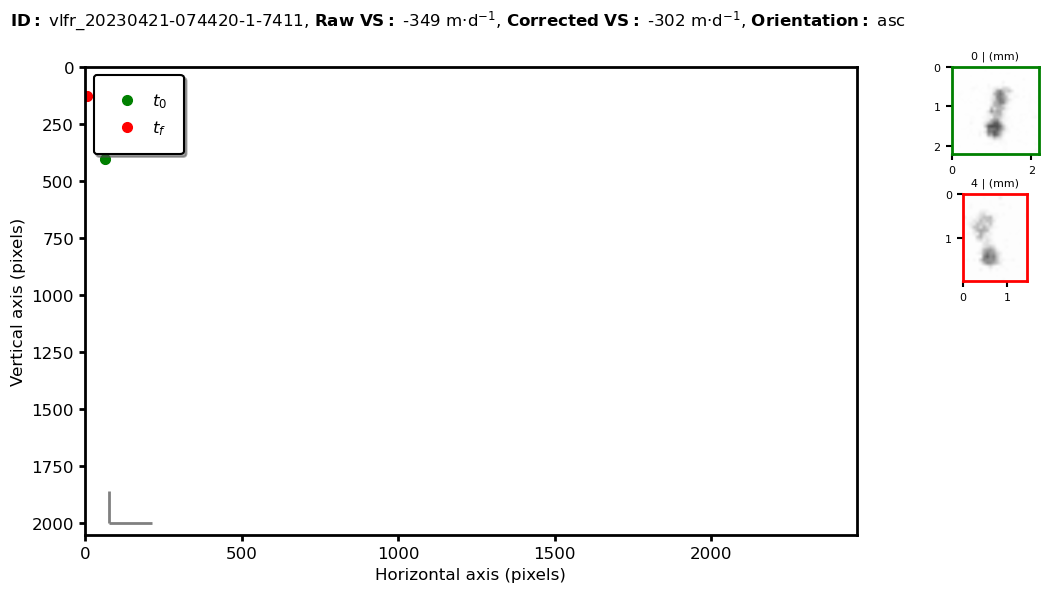

Process done for this sequence.
Delete images from local
Processing sequence 9/19: 20230421-185822
extract images from server to local
Processing track 0/1: vlfr_20230421-190102-1-3080


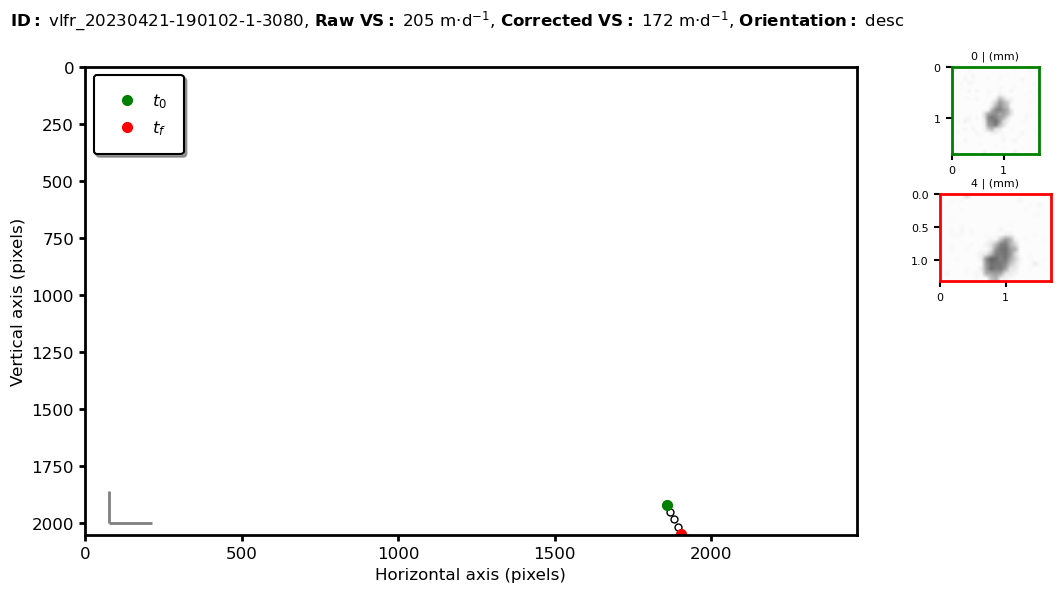

Process done for this sequence.
Delete images from local
Processing sequence 10/19: 20230423-001139
extract images from server to local
Processing track 0/7: vlfr_20230423-001340-1-2282


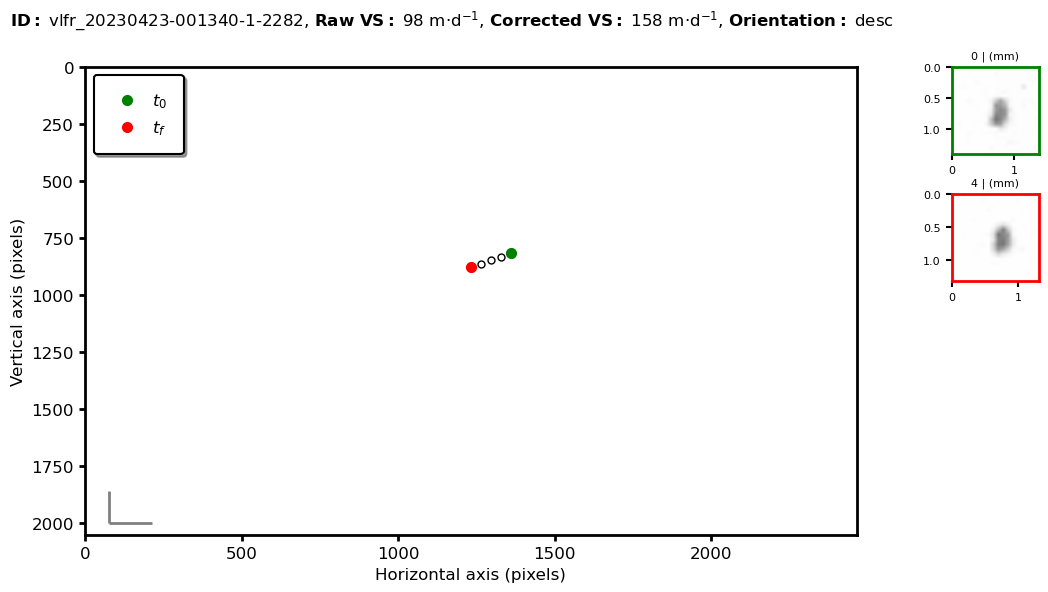

Processing track 0/7: vlfr_20230423-001458-1-4200


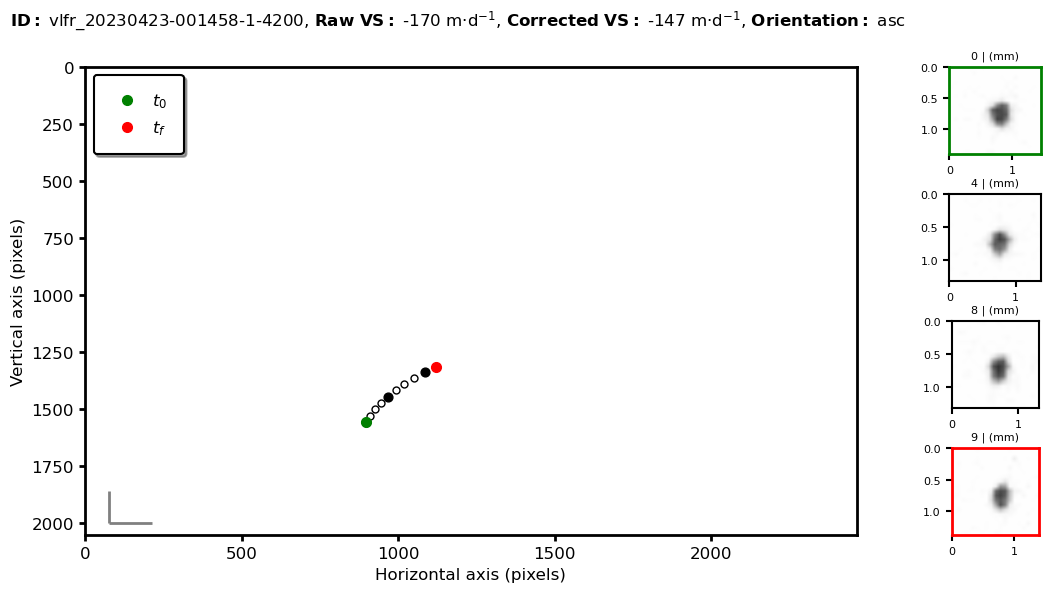

Processing track 0/7: vlfr_20230423-001642-1-6678


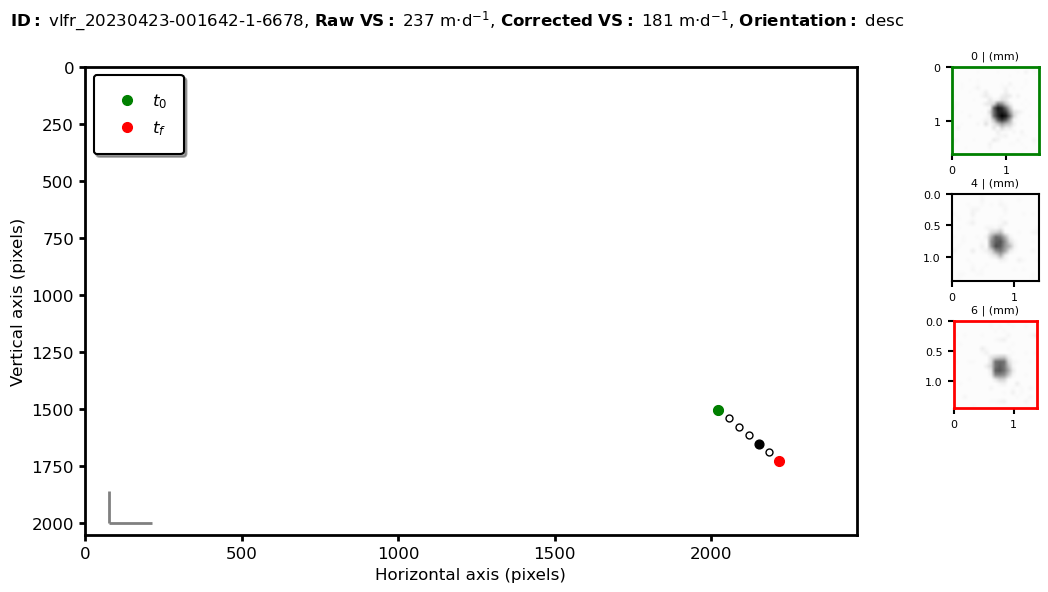

Processing track 0/7: vlfr_20230423-001649-1-6833


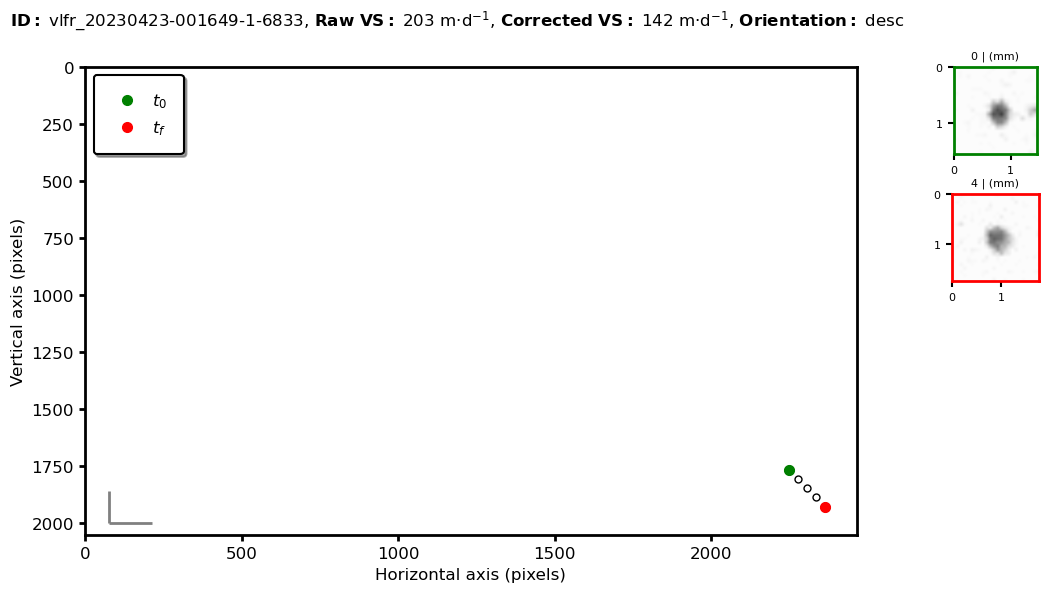

Processing track 0/7: vlfr_20230423-001724-1-7665


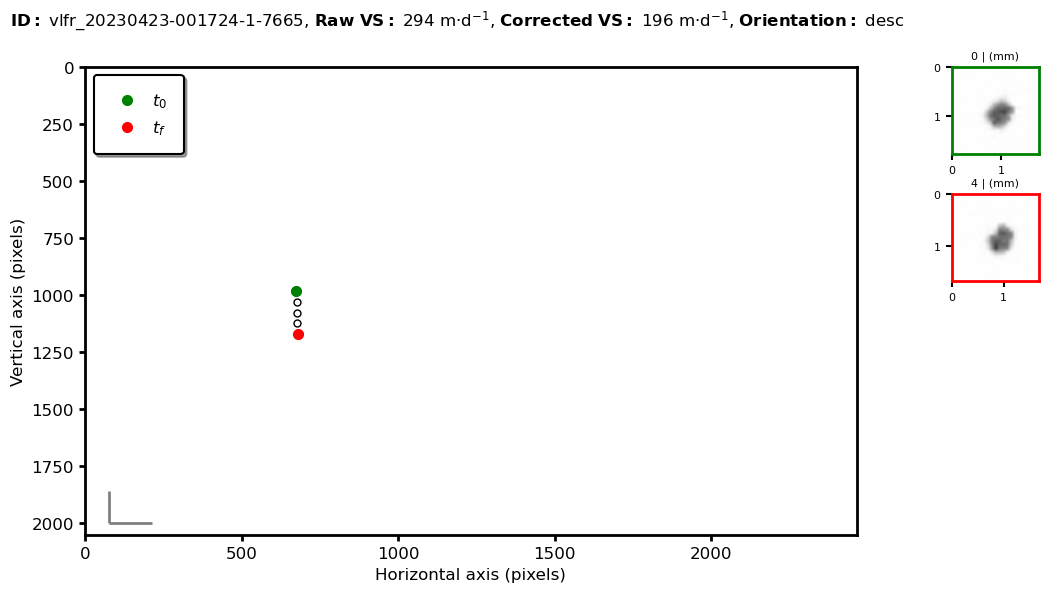

Processing track 0/7: vlfr_20230423-001756-1-8412


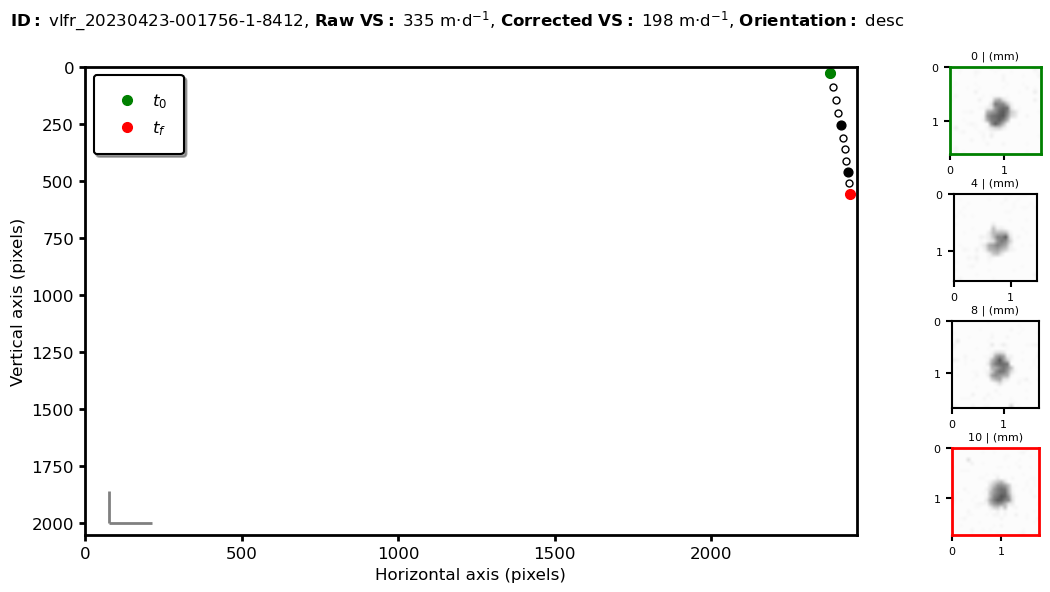

Processing track 0/7: vlfr_20230423-001845-1-9538


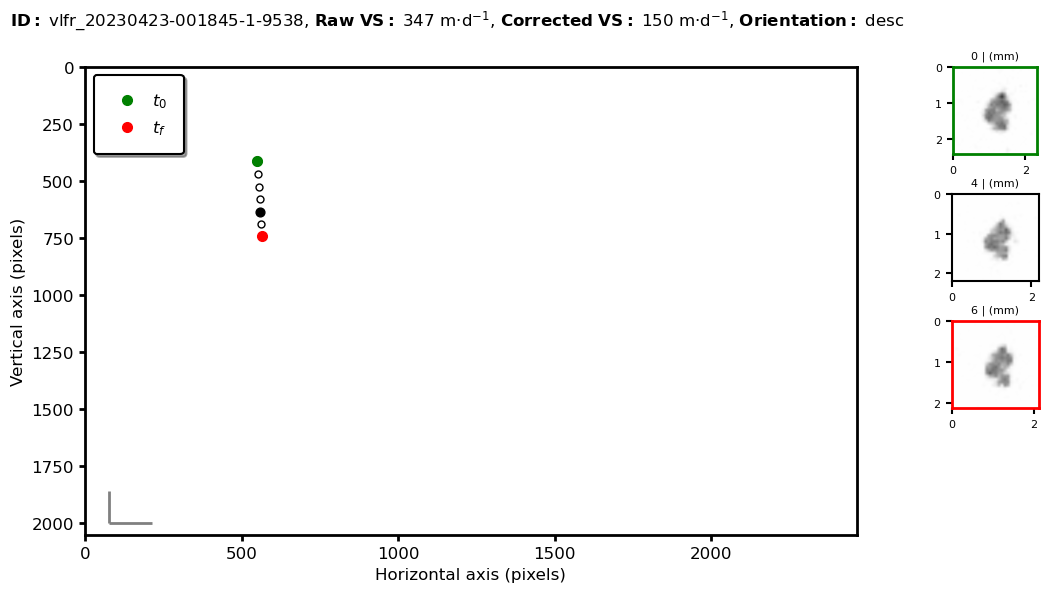

Process done for this sequence.
Delete images from local
Processing sequence 11/19: 20230423-181011
extract images from server to local
Processing track 0/4: vlfr_20230423-181058-1-664


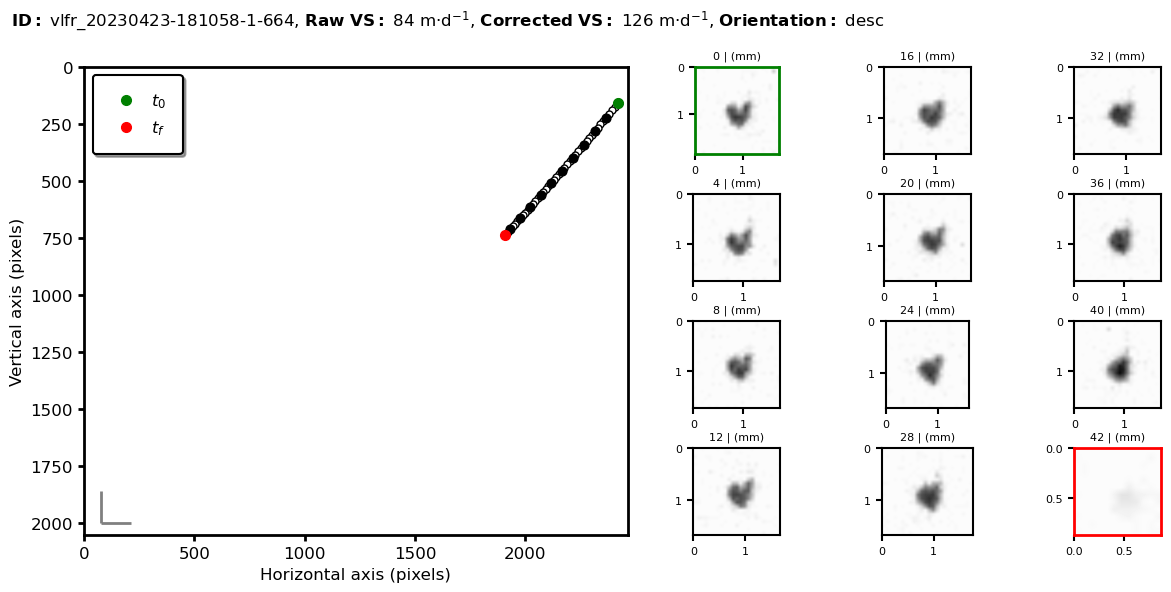

Processing track 0/4: vlfr_20230423-181151-1-2143


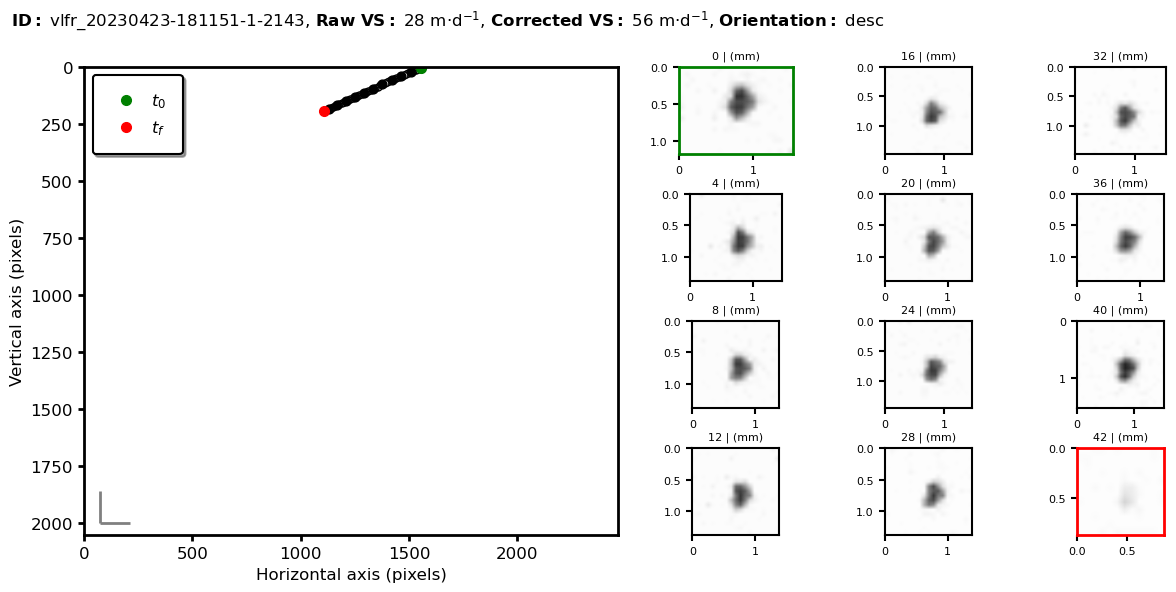

Processing track 0/4: vlfr_20230423-181255-1-3918


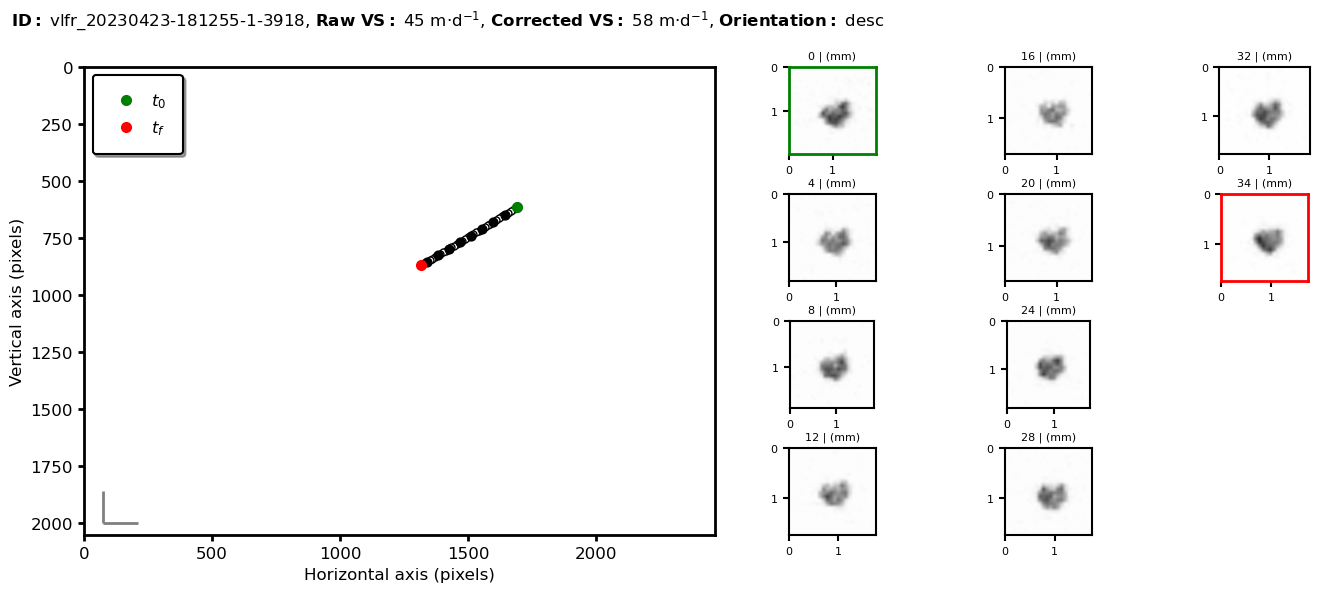

Processing track 0/4: vlfr_20230423-181445-1-7105


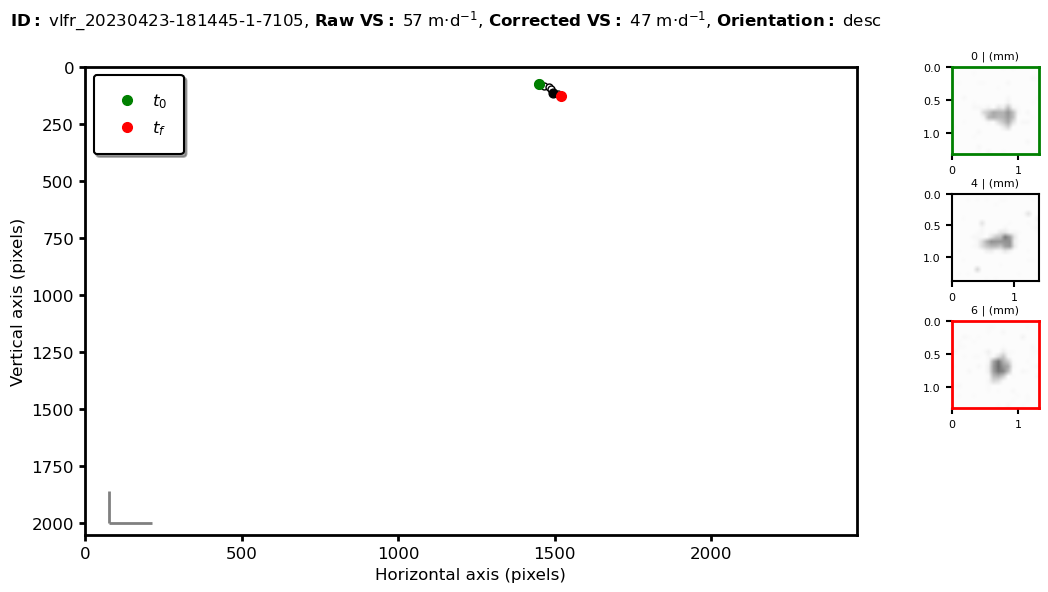

Process done for this sequence.
Delete images from local
Processing sequence 12/19: 20230423-193011
extract images from server to local
Processing track 0/1: vlfr_20230423-193057-1-555


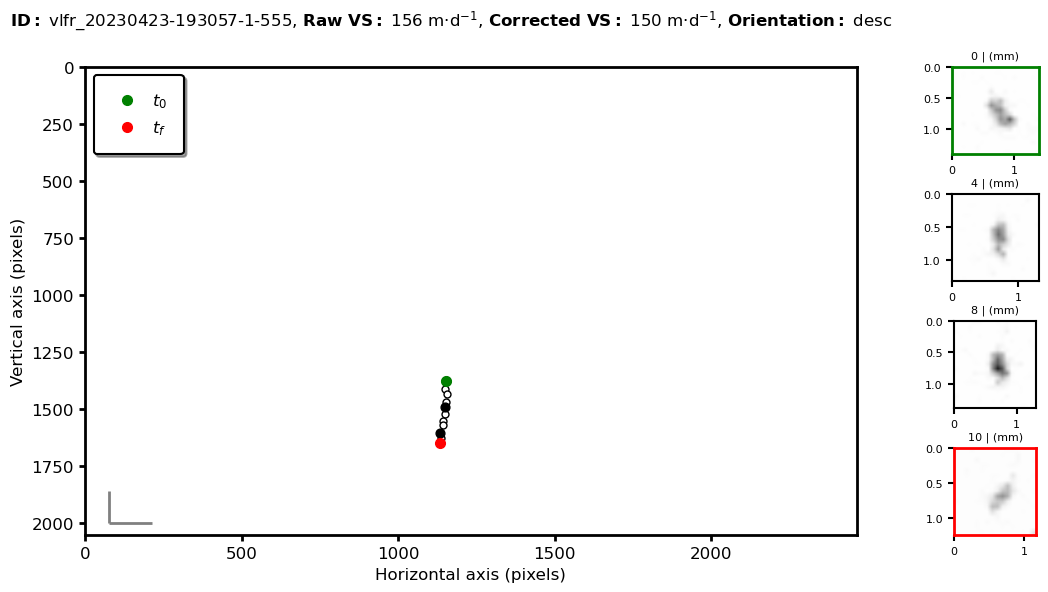

Process done for this sequence.
Delete images from local
Processing sequence 13/19: 20230425-183809
extract images from server to local
Processing track 0/5: vlfr_20230425-184056-1-5003


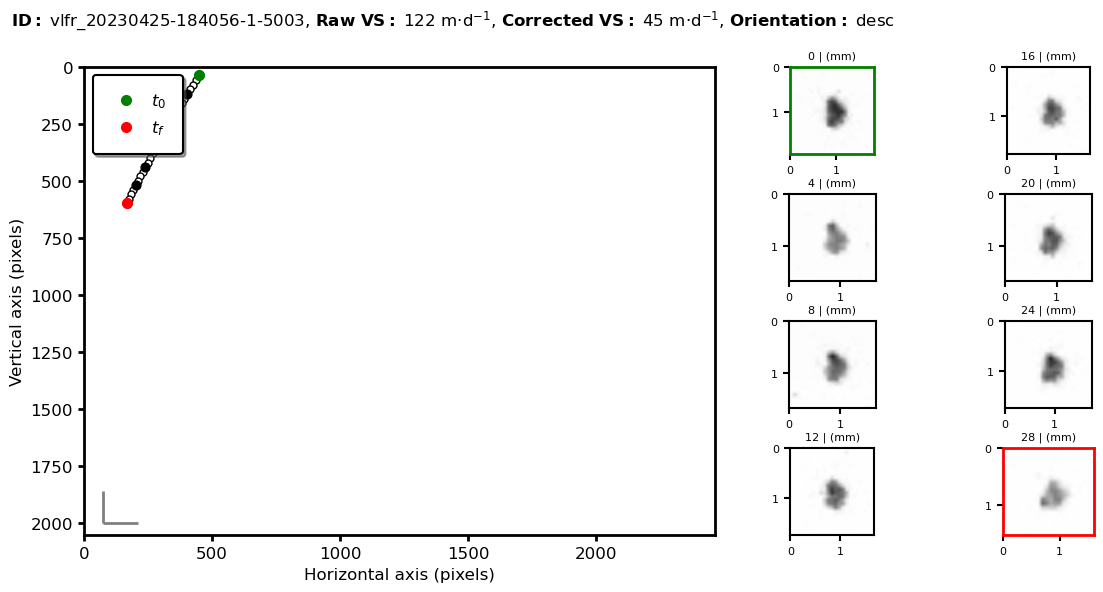

Processing track 0/5: vlfr_20230425-184150-1-7081


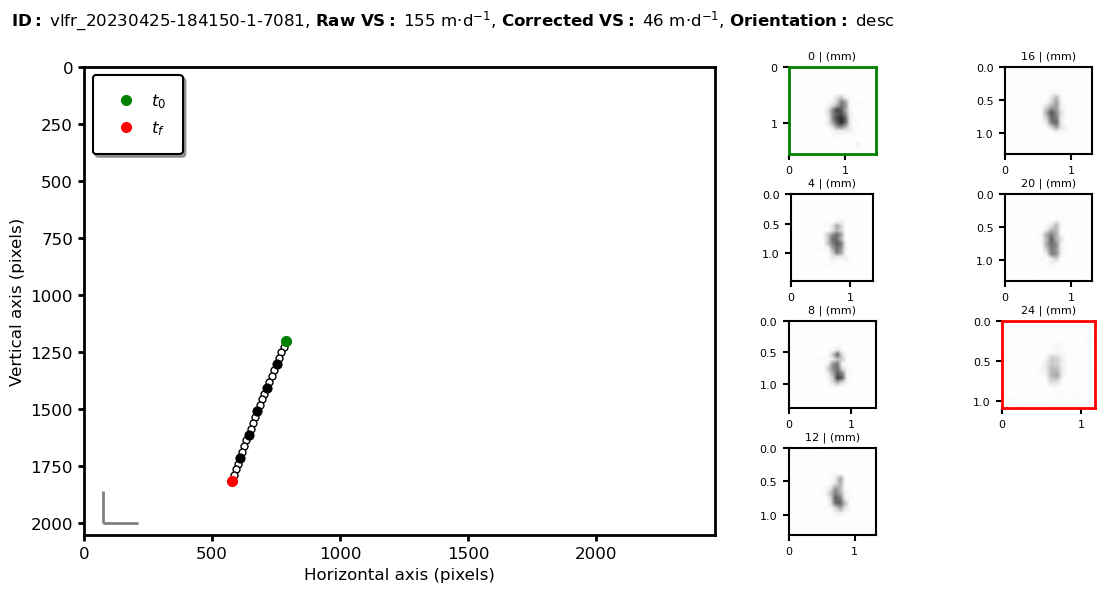

Processing track 0/5: vlfr_20230425-184222-1-8236


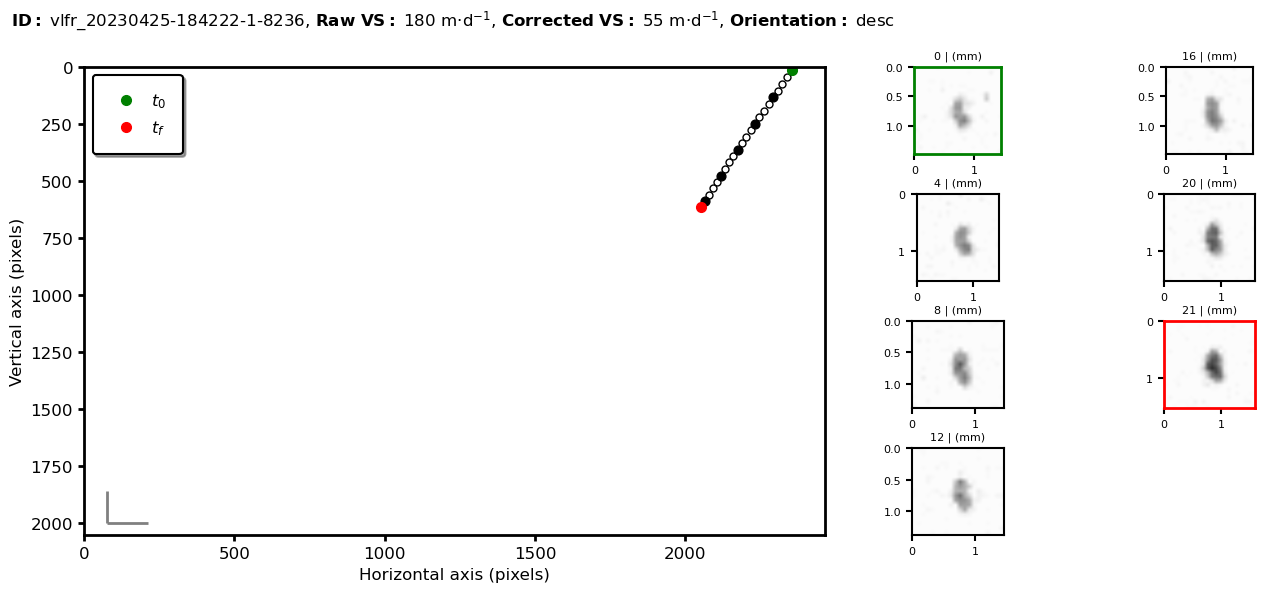

Processing track 0/5: vlfr_20230425-184306-1-9672


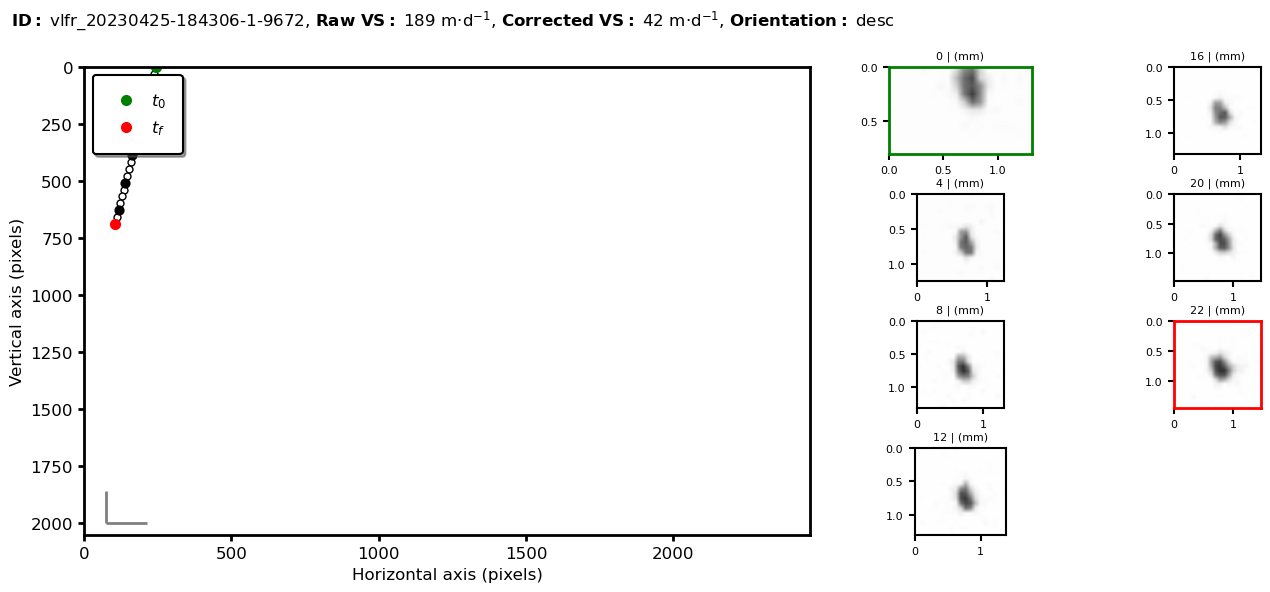

Processing track 0/5: vlfr_20230425-184315-1-9997


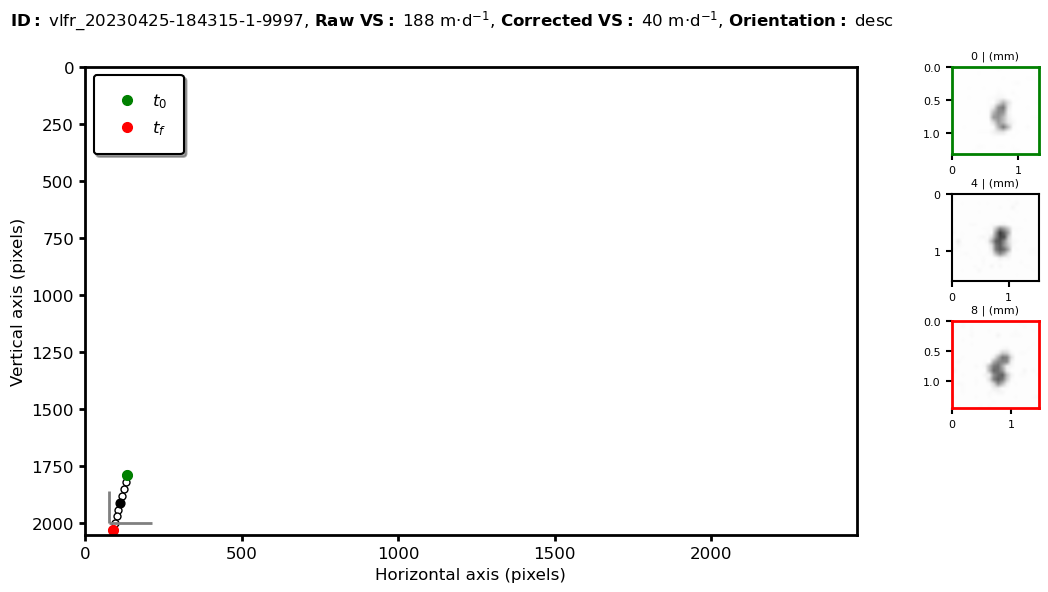

Process done for this sequence.
Delete images from local
Processing sequence 14/19: 20230426-055807
extract images from server to local
Processing track 0/1: vlfr_20230426-060232-1-7963


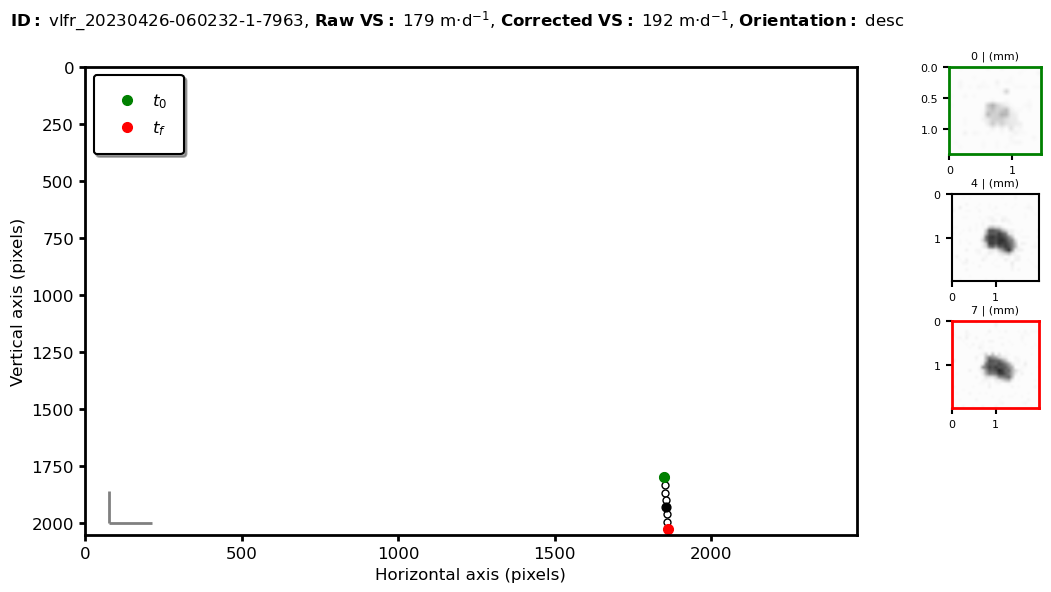

Process done for this sequence.
Delete images from local
Processing sequence 15/19: 20230428-035517
extract images from server to local
Processing track 0/2: vlfr_20230428-035541-1-57


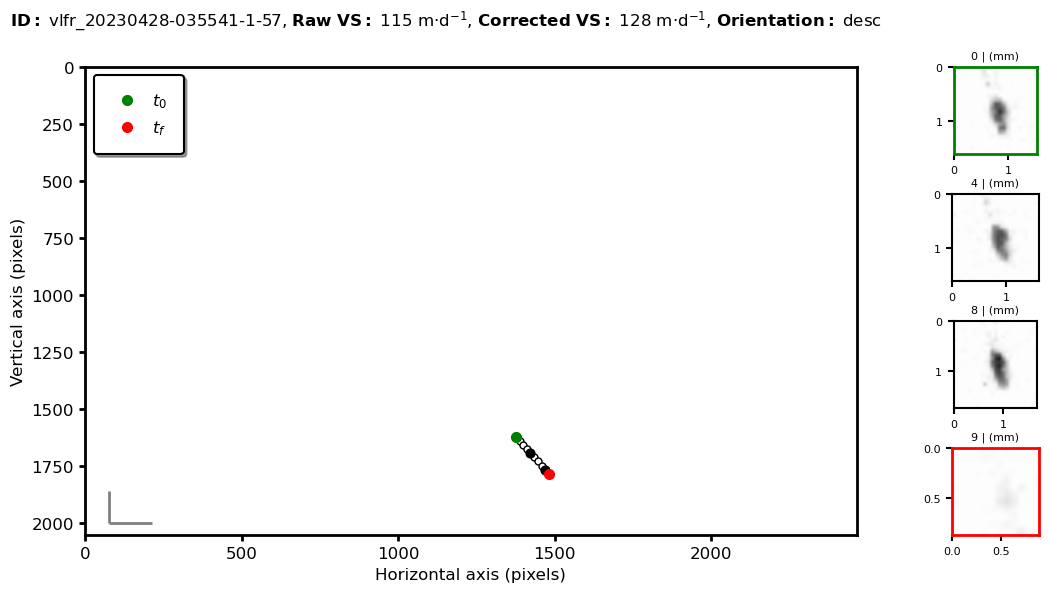

Processing track 0/2: vlfr_20230428-040223-1-18806


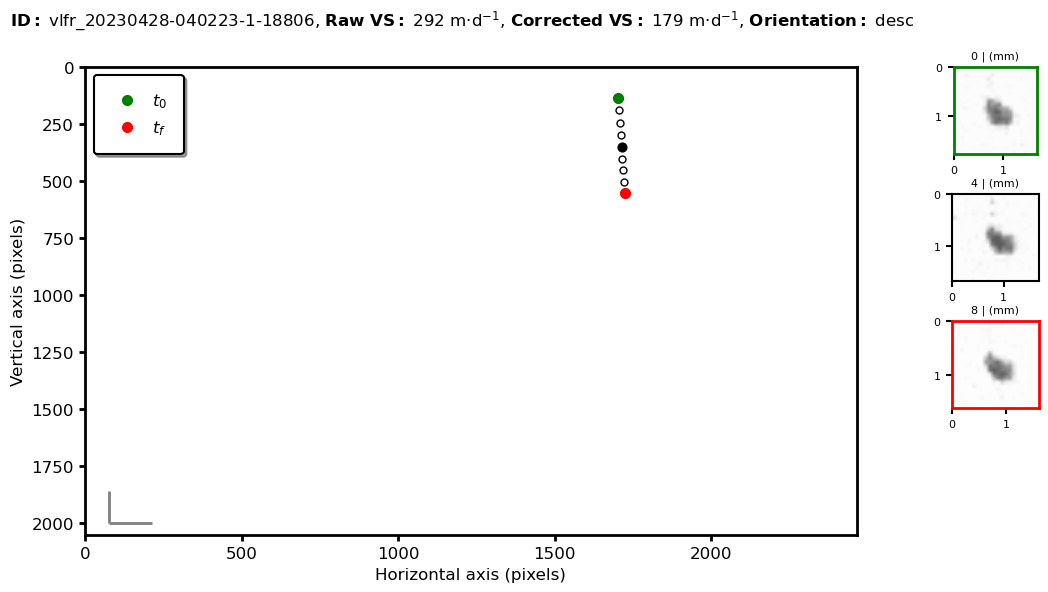

Process done for this sequence.
Delete images from local
Processing sequence 16/19: 20230428-055517
extract images from server to local
Processing track 0/2: vlfr_20230428-055918-1-9415


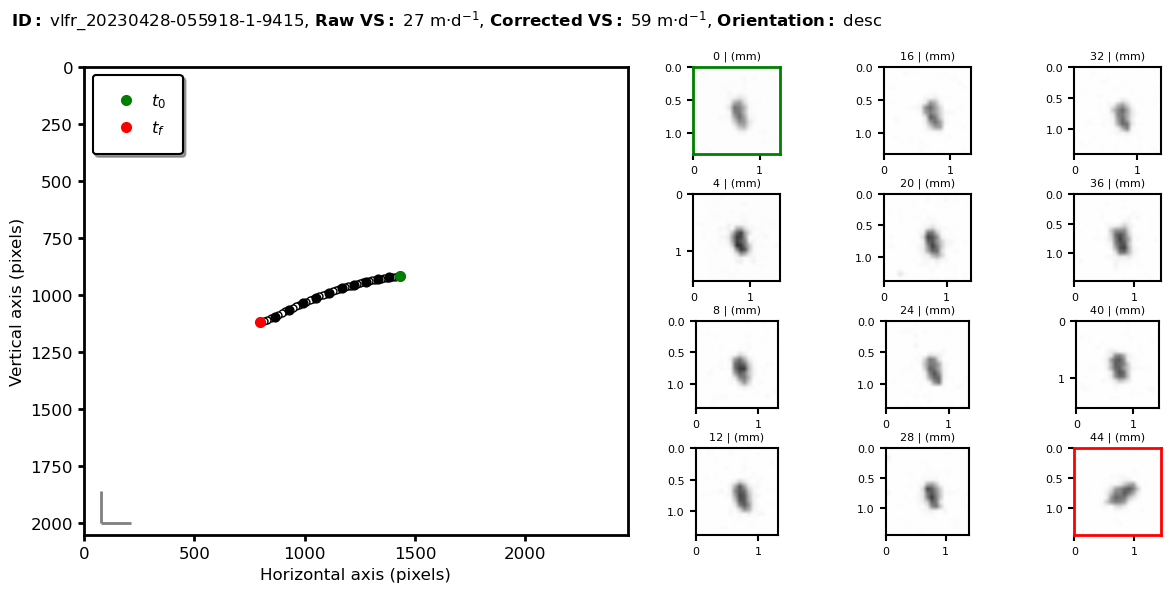

Processing track 0/2: vlfr_20230428-060114-1-13914


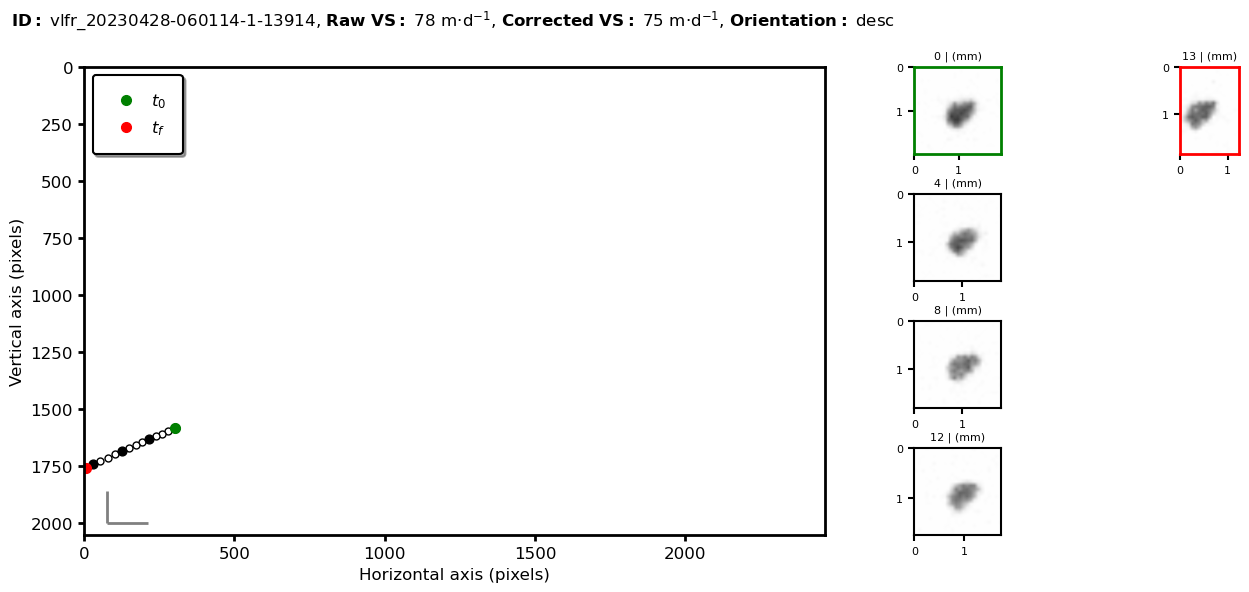

Process done for this sequence.
Delete images from local
Processing sequence 17/19: 20230428-091517
extract images from server to local
Processing track 0/3: vlfr_20230428-091603-1-834


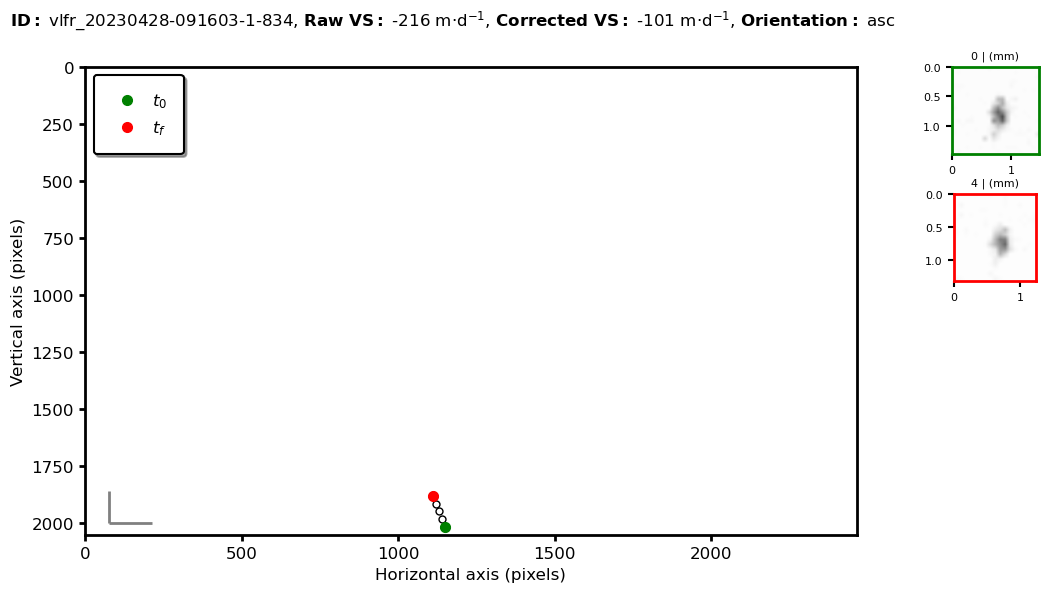

Processing track 0/3: vlfr_20230428-091606-1-943


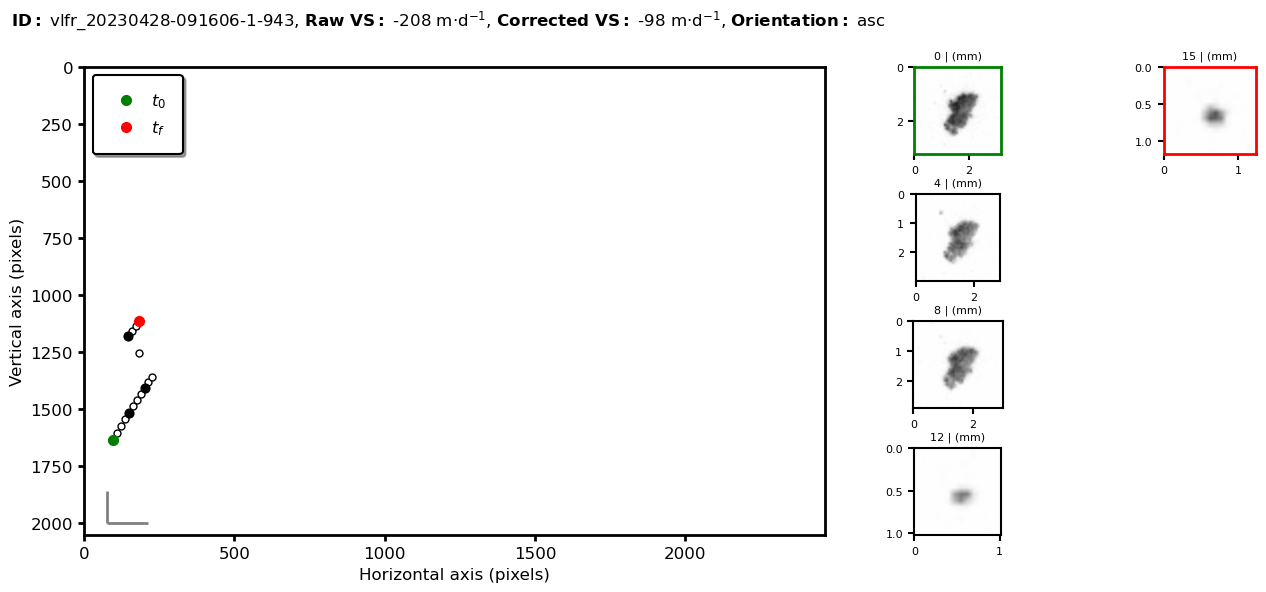

Processing track 0/3: vlfr_20230428-091630-1-1980


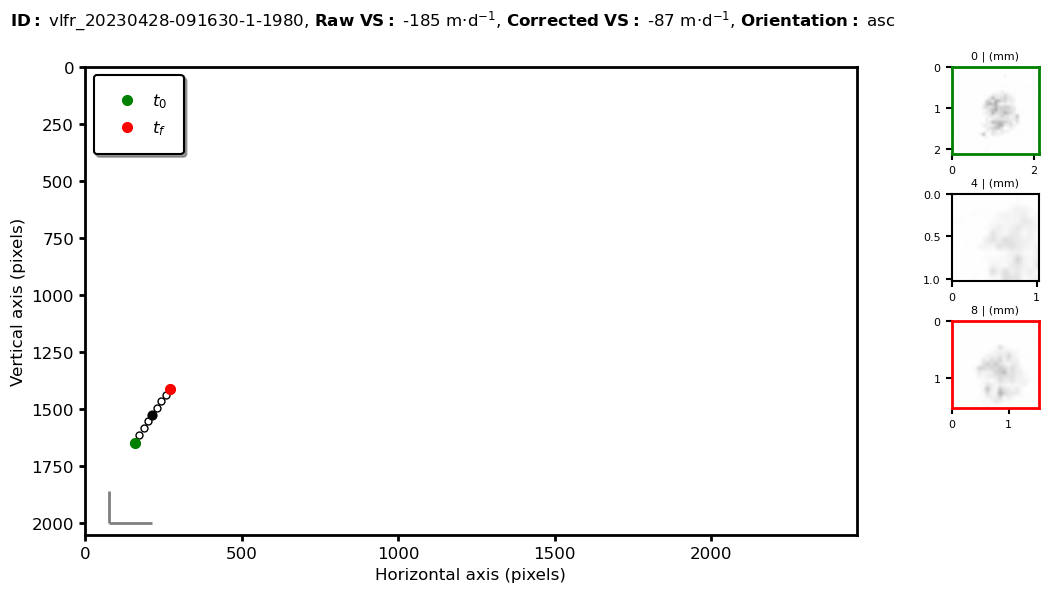

Process done for this sequence.
Delete images from local
Processing sequence 18/19: 20230428-143517
extract images from server to local
Processing track 0/1: vlfr_20230428-143855-1-9218


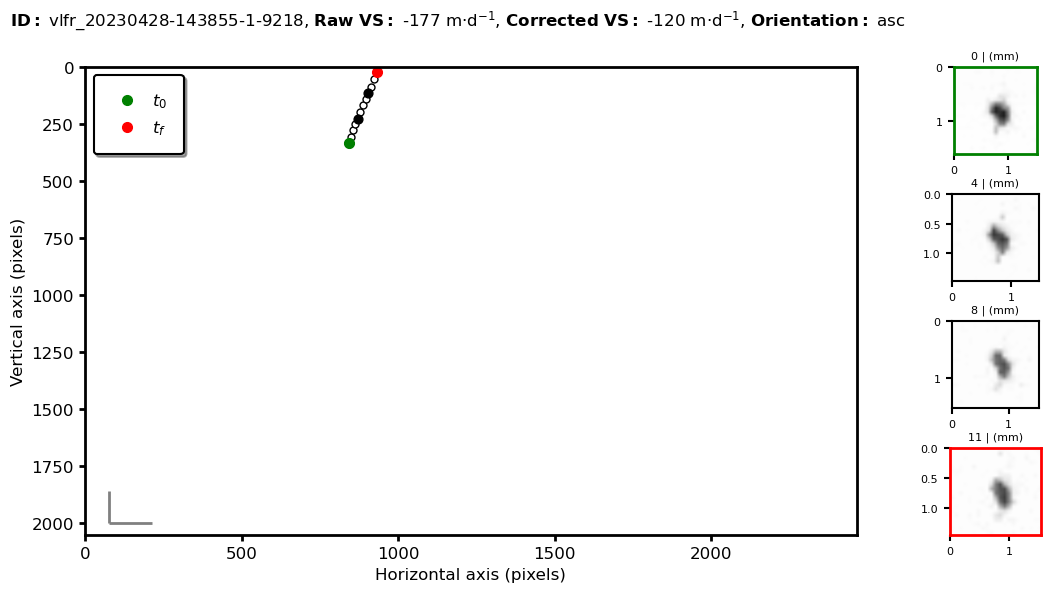

Process done for this sequence.
Delete images from local
Processing sequence 19/19: 20230428-151517
extract images from server to local
Processing track 0/2: vlfr_20230428-151610-1-1312


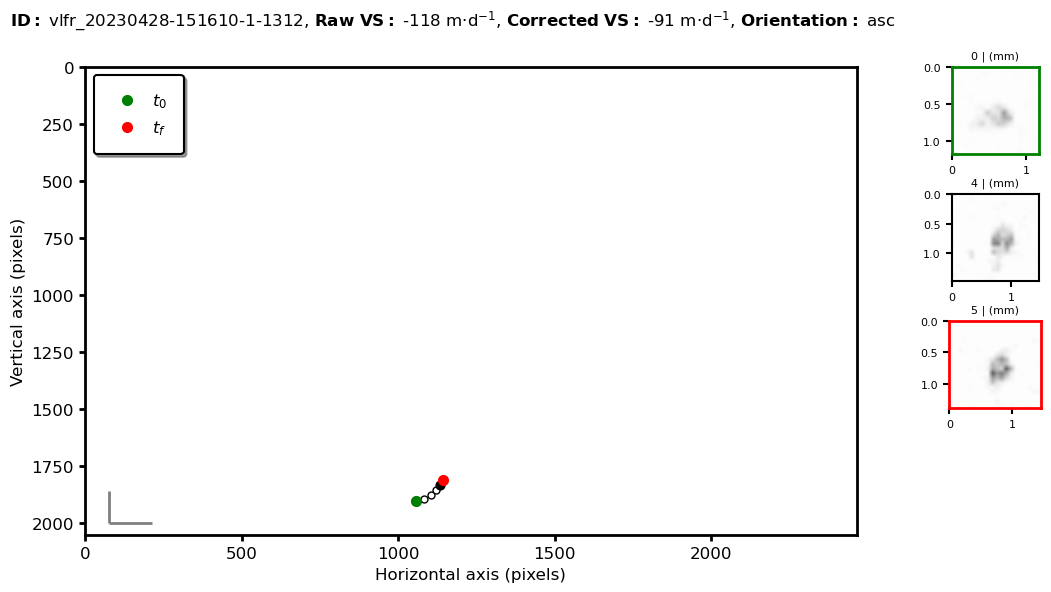

Processing track 0/2: vlfr_20230428-151618-1-1700


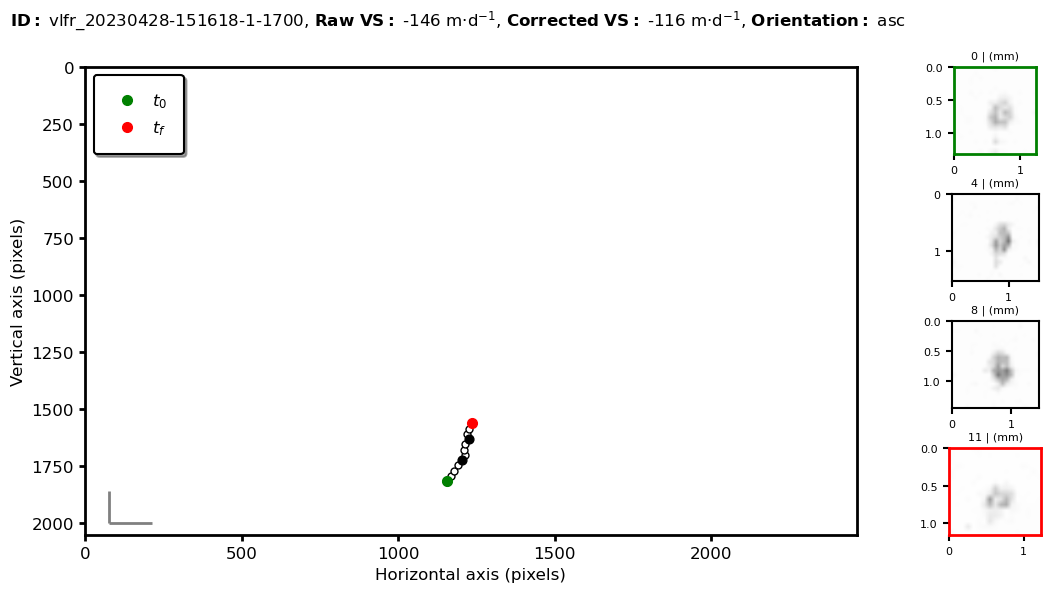

Process done for this sequence.
Delete images from local
Processing sequence 20/19: 20230428-175517
extract images from server to local
Processing track 0/1: vlfr_20230428-175923-1-10601


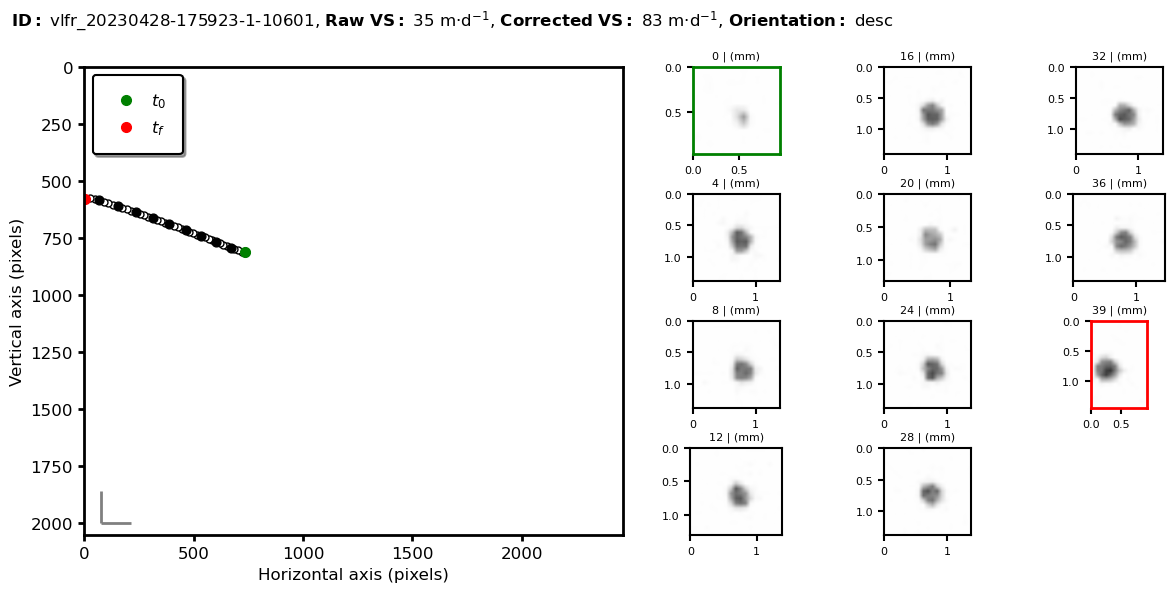

Process done for this sequence.
Delete images from local
Processing sequence 21/19: 20230429-150426
extract images from server to local
Processing track 0/2: vlfr_20230429-150651-1-3704


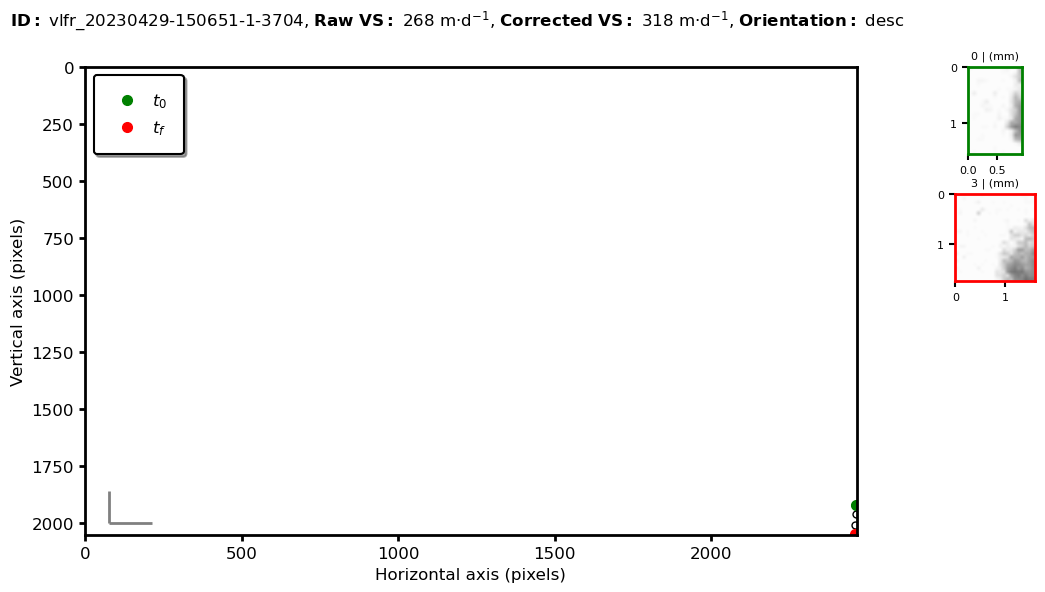

Processing track 0/2: vlfr_20230429-150942-1-9118


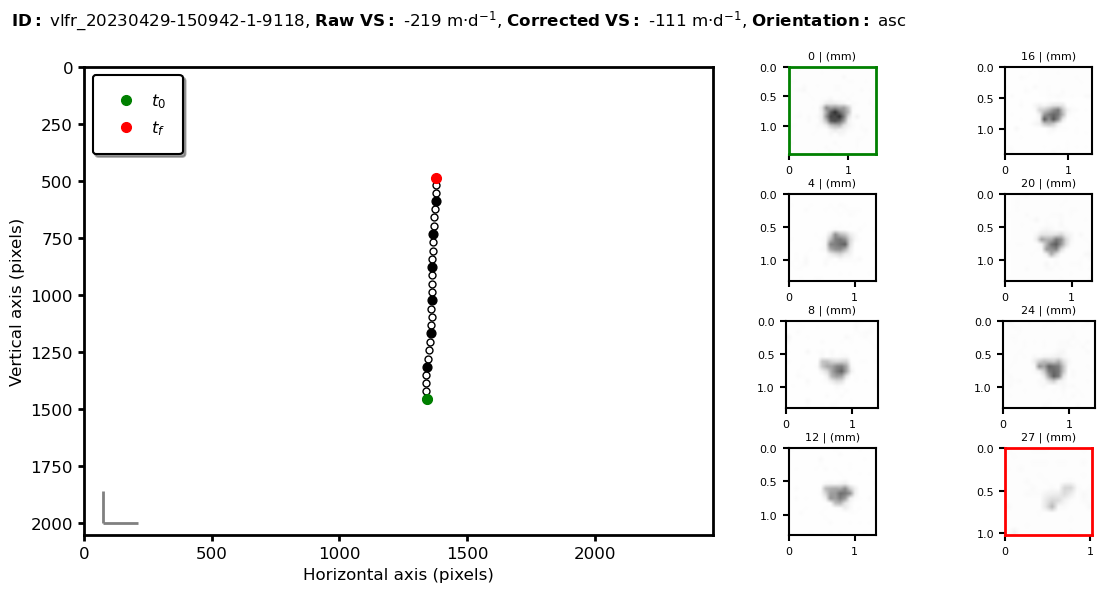

Process done for this sequence.
Delete images from local
Processing sequence 22/19: 20230429-154426
extract images from server to local
Processing track 0/5: vlfr_20230429-154450-1-32


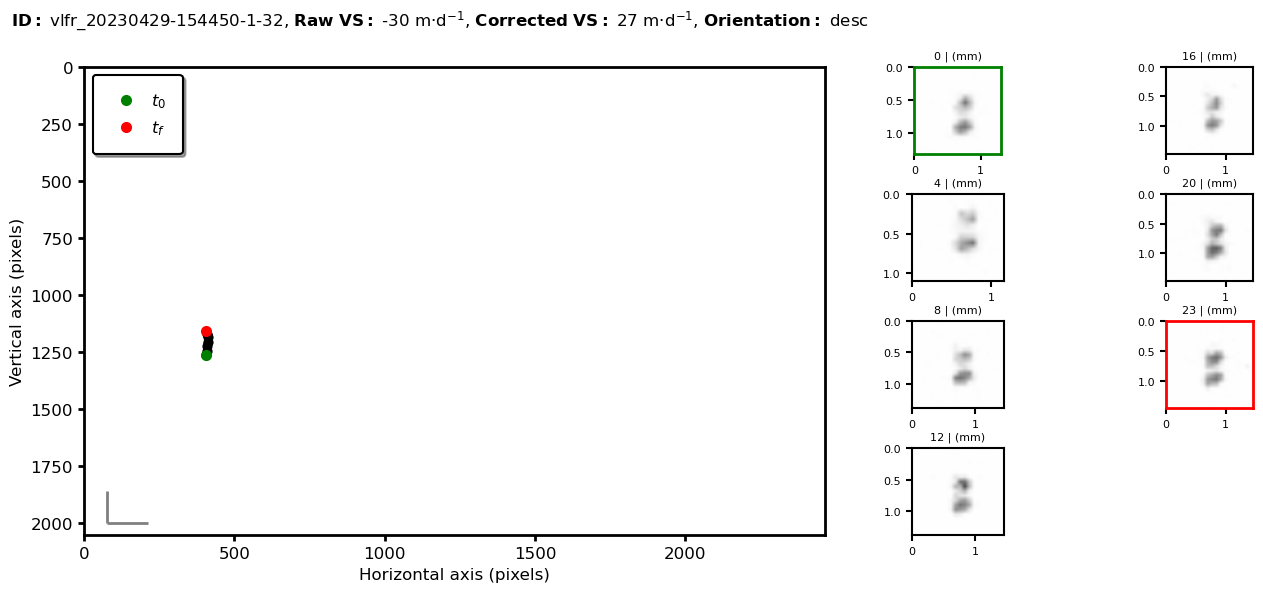

Processing track 0/5: vlfr_20230429-154542-1-1435


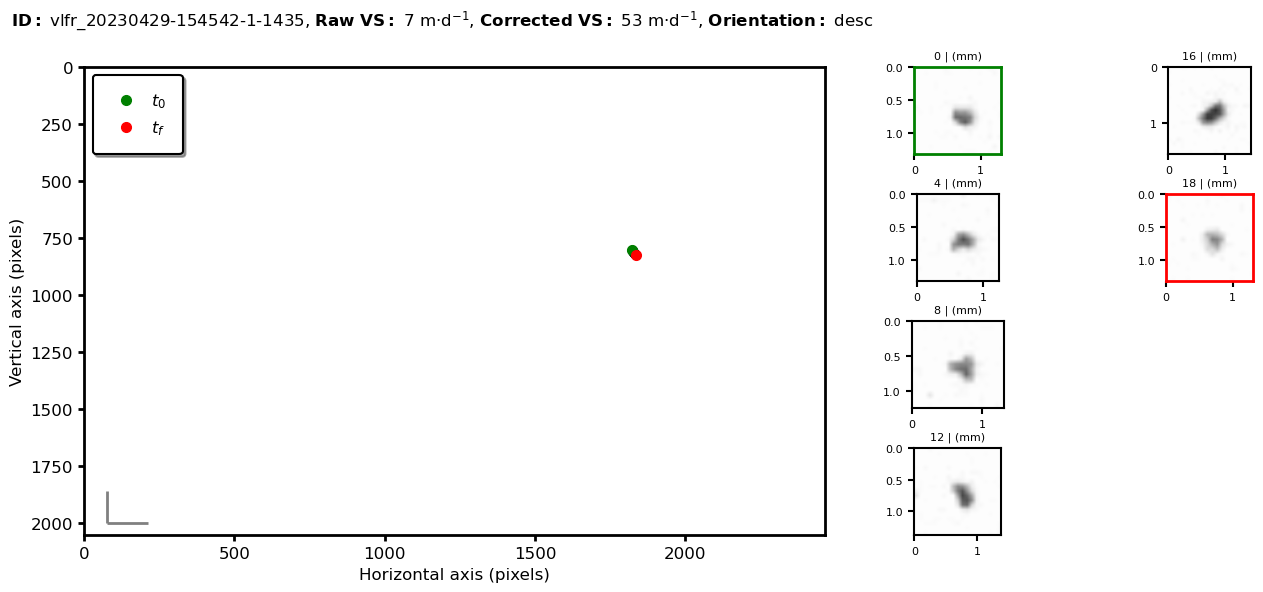

Processing track 0/5: vlfr_20230429-154654-1-4011


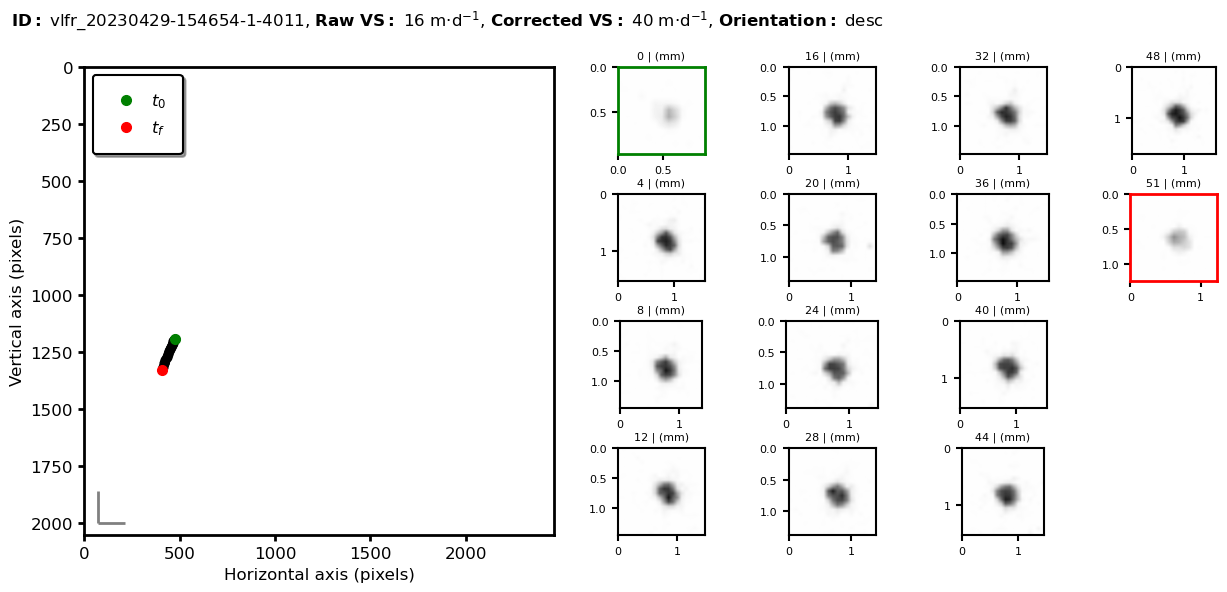

Processing track 0/5: vlfr_20230429-154724-1-5276


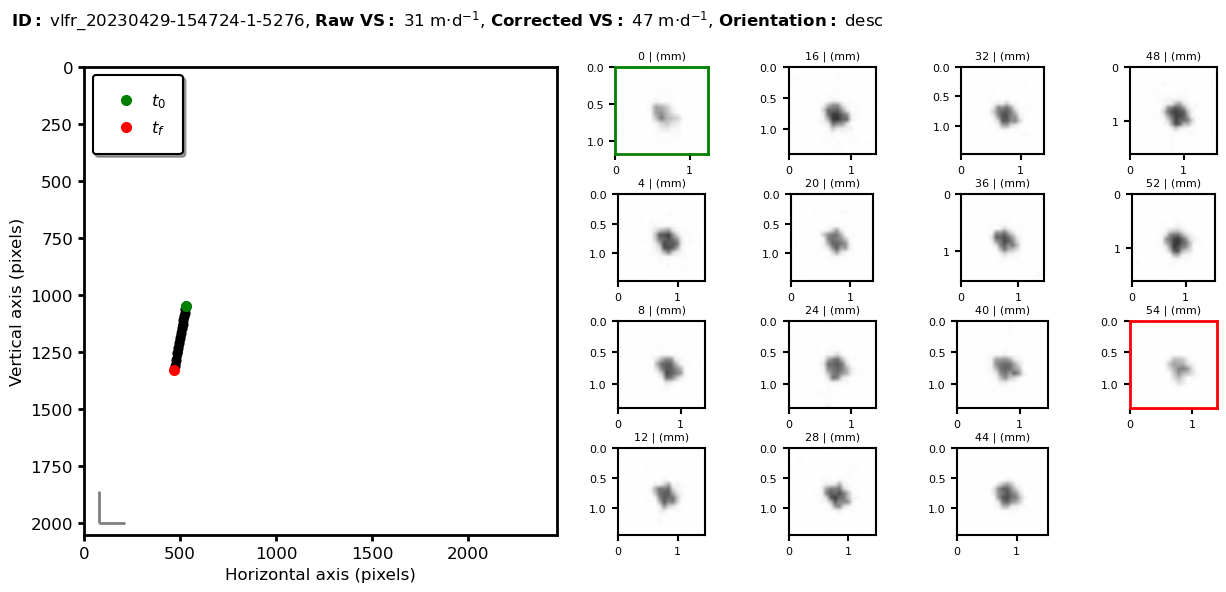

Processing track 0/5: vlfr_20230429-155055-1-11618


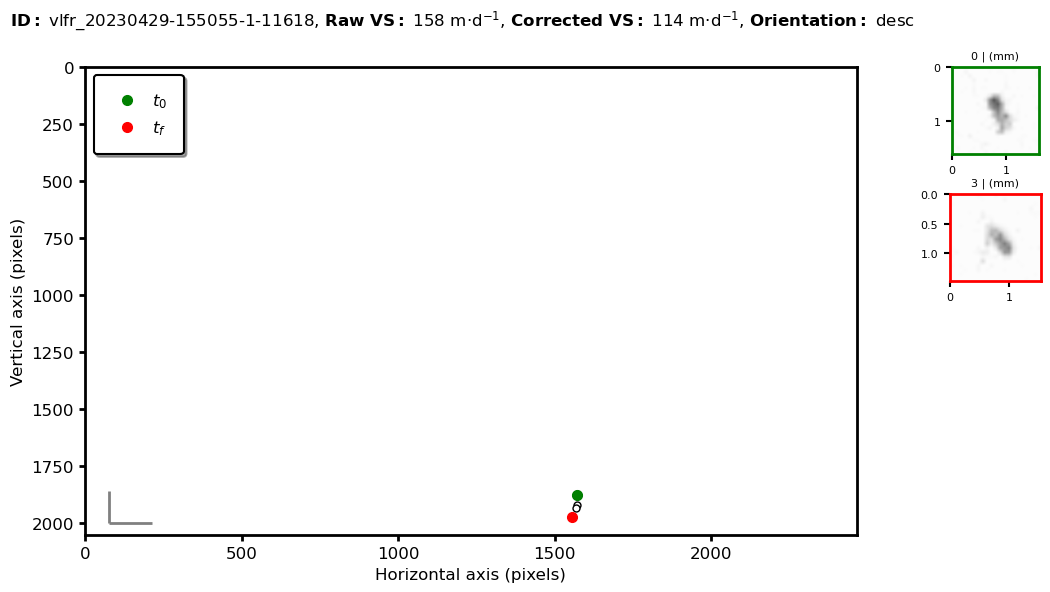

Process done for this sequence.
Delete images from local
Processing sequence 23/19: 20230501-063321
extract images from server to local
Processing track 0/1: vlfr_20230501-063436-1-1392


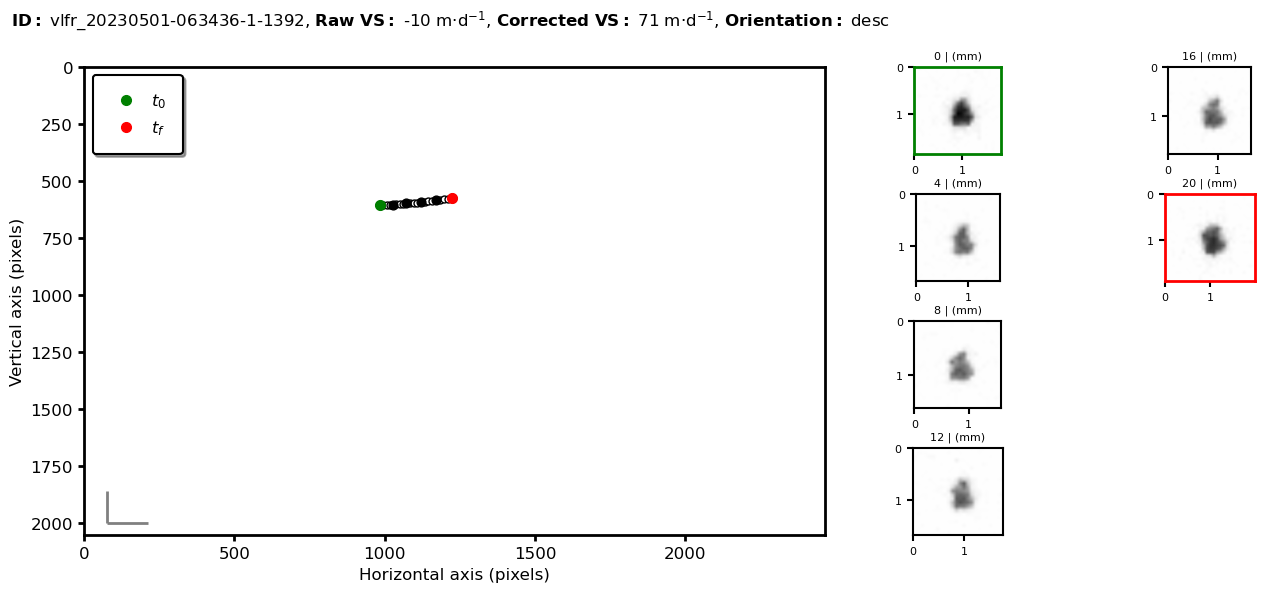

Process done for this sequence.
Delete images from local
Process done.


In [29]:
for sequence in sequences:
    count_seq += 1
    print(f'Processing sequence {count_seq}/{total_sequences}: {sequence}')
    df_sequence = VLFR_tracks[VLFR_tracks['sequence'] == sequence]

    # extract images from server 
    sequence = df_sequence['sequence'].iloc[0]
    source_directory = '/home/aaccardo/plankton/_uvp6_missions_archives/uvp6_sn000146lp/uvp6_sn000146lp_202304_sed_float_vlfr'
    dir_raw = os.path.join(source_directory, 'raw')
    dest_directory = '/home/aaccardo/these_alex/Papers/Rising_stars/Track_plots'
    dir_copy_raw = os.path.join(dest_directory, 'copy_raw')

    # Define the path to the zip file that contains the raw images
    path_zip = os.path.join(dir_raw, sequence, 'images.zip')
    # Check if the path exists
    if os.path.exists(path_zip):
        # Extract the images
        archive = zipfile.ZipFile(path_zip)
        names = [i for i in archive.namelist() 
                 if not i.startswith('images')]
        print('extract images from server to local')
        for file in names:
            archive.extract(file, os.path.join(dir_copy_raw, sequence))
            
    # Define the list with track_id
    track_id = df_sequence['track_id'].unique().tolist()
    total_tracks = len(track_id)
    count_track = 0 
    
    # Loop over tracks
    for track in track_id:
        count_track += 1
        print(f'Processing track {count}/{total_tracks}: {track}')
    
        # Select the corresponding track from the summary dataframe
        data = df_sequence[df_sequence['track_id'] == track]
        #print(data)
    
        
        # Create the figure
        plot_track_and_vignettes_VLFR(df_particles = data, disp_step = 4)
   
    print('Process done for this sequence.')
    # Delete the temporary copy raw folder
    print('Delete images from local')
    shutil.rmtree(os.path.join(dir_copy_raw, sequence))

print('Process done.')    

# Focus on a specific track 

In [34]:
test_df = VLFR_tracks[VLFR_tracks['track_id'] == 'vlfr_20230428-143855-1-9218']
test_df

,track_id,orientation_corrected,orientation_raw,vertical_speed,corrected_by_poly,esd_um,sequence,coord_x,coord_y,esd_px,filename,step_num
3533,vlfr_20230428-143855-1-9218,asc,asc,-177.099977,-119.893126,384.774296,20230428-143517,842.945946,333.216216,6.863663,/home/aaccardo/these_alex/Papers/Rising_stars/...,0
3534,vlfr_20230428-143855-1-9218,asc,asc,-177.099977,-119.893126,384.774296,20230428-143517,849.351351,306.486486,6.863663,/home/aaccardo/these_alex/Papers/Rising_stars/...,1
3535,vlfr_20230428-143855-1-9218,asc,asc,-177.099977,-119.893126,384.774296,20230428-143517,856.218750,278.437500,6.383076,/home/aaccardo/these_alex/Papers/Rising_stars/...,2
3536,vlfr_20230428-143855-1-9218,asc,asc,-177.099977,-119.893126,384.774296,20230428-143517,863.071429,252.178571,5.970821,/home/aaccardo/these_alex/Papers/Rising_stars/...,3
3537,vlfr_20230428-143855-1-9218,asc,asc,-177.099977,-119.893126,384.774296,20230428-143517,870.214286,228.214286,5.970821,/home/aaccardo/these_alex/Papers/Rising_stars/...,4
3538,vlfr_20230428-143855-1-9218,asc,asc,-177.099977,-119.893126,384.774296,20230428-143517,878.187500,199.687500,6.383076,/home/aaccardo/these_alex/Papers/Rising_stars/...,5
3539,vlfr_20230428-143855-1-9218,asc,asc,-177.099977,-119.893126,384.774296,20230428-143517,887.034483,168.517241,6.076508,/home/aaccardo/these_alex/Papers/Rising_stars/...,6
3540,vlfr_20230428-143855-1-9218,asc,asc,-177.099977,-119.893126,384.774296,20230428-143517,895.666667,139.878788,6.482045,/home/aaccardo/these_alex/Papers/Rising_stars/...,7
3541,vlfr_20230428-143855-1-9218,asc,asc,-177.099977,-119.893126,384.774296,20230428-143517,904.151515,113.606061,6.482045,/home/aaccardo/these_alex/Papers/Rising_stars/...,8
3542,vlfr_20230428-143855-1-9218,asc,asc,-177.099977,-119.893126,384.774296,20230428-143517,913.133333,87.266667,6.180387,/home/aaccardo/these_alex/Papers/Rising_stars/...,9


In [35]:
sequences = test_df['sequence'].unique().tolist()
total_sequences = len(sequences)
count_seq = 0 

Processing sequence 7/1: 20230428-143517
extract images from server to local
Processing track 1/1: vlfr_20230428-143855-1-9218
Could not create the figure: index 5 is out of bounds for axis 1 with size 5
Process done for this sequence.
Delete images from local
Process done.


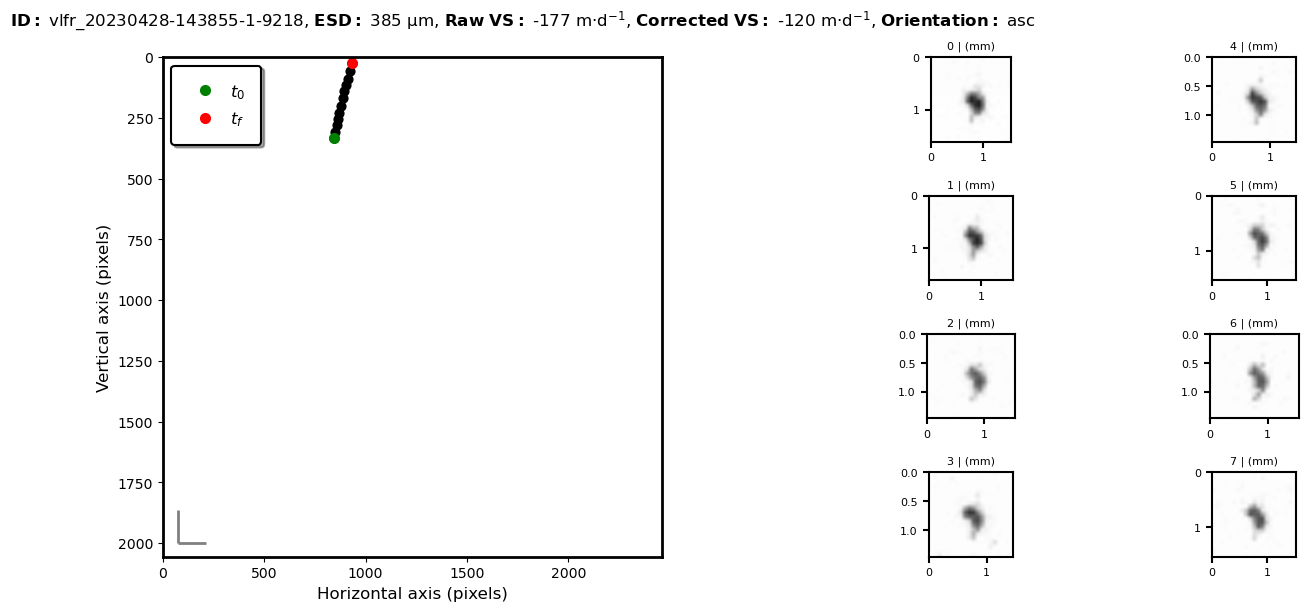

In [47]:
for sequence in sequences:
    count_seq += 1
    print(f'Processing sequence {count_seq}/{total_sequences}: {sequence}')
    df_sequence = test_df[test_df['sequence'] == sequence]

    # extract images from server 
    sequence = df_sequence['sequence'].iloc[0]
    source_directory = '/home/aaccardo/plankton/_uvp6_missions_archives/uvp6_sn000146lp/uvp6_sn000146lp_202304_sed_float_vlfr'
    dir_raw = os.path.join(source_directory, 'raw')
    dest_directory = '/home/aaccardo/these_alex/Papers/Rising_stars/Track_plots'
    dir_copy_raw = os.path.join(dest_directory, 'copy_raw')

    # Define the path to the zip file that contains the raw images
    path_zip = os.path.join(dir_raw, sequence, 'images.zip')
    # Check if the path exists
    if os.path.exists(path_zip):
        # Extract the images
        archive = zipfile.ZipFile(path_zip)
        names = [i for i in archive.namelist() 
                 if not i.startswith('images')]
        print('extract images from server to local')
        for file in names:
            archive.extract(file, os.path.join(dir_copy_raw, sequence))
            
    # Define the list with track_id
    track_id = df_sequence['track_id'].unique().tolist()
    total_tracks = len(track_id)
    count_track = 0 
    
    # Loop over tracks
    for track in track_id:
        count_track += 1
        print(f'Processing track {count_track}/{total_tracks}: {track}')
    
        # Select the corresponding track from the summary dataframe
        data = df_sequence[df_sequence['track_id'] == track]
        #print(data)
    
        
        # Create the figure
        plot_track_and_vignettes_VLFR(df_particles = data, disp_step = 1, save_path='/home/aaccardo/these_alex/Papers/Rising_stars/Track_plots/Figures')
   
    print('Process done for this sequence.')
    # Delete the temporary copy raw folder
    print('Delete images from local')
    shutil.rmtree(os.path.join(dir_copy_raw, sequence))

print('Process done.')    